In [ ]:
#Generate MCEq Grid run once
from MCEq.core import MCEqRun
import crflux.models as crf
import MCEq.config as config
from MCEq.geometry.density_profiles import MSIS00Atmosphere
from MCEq.geometry.geometry import EarthGeometry
config.kernel_config= 'MKL'
config.e_min = 0.160 # GeV
config.integrator= 'euler'
import numpy as np
import crflux.models as pm
import matplotlib.pyplot as plt
# generate_mceq_grid.py
import pickle
# Initalize MCEq by creating the user interface object MCEqRun
# Initialize custom atmosphere model with coordinates
# Note: Using custom location with latitude/longitude parameters
mag = 0
# Initialize MCEq with custom atmosphere and Frisco Peak location
mceq = MCEqRun(
    # interaction interaction model
    interaction_model='SIBYLL23C',
    # Primary cosmic ray model
    primary_model=(pm.GlobalSplineFitBeta, None),
    # Set to 0° for horizontal muons
    theta_deg=0.,
    # Use custom atmosphere and geometry
    density_model=("CORSIKA", ('USStd', None)),
    #density_model=("MSIS00_IC", ('FriscoPeak', 'January')),
)
#mceq.set_density_model(("CORSIKA", ('USStd', None)))
earth_geom = EarthGeometry()
def get_spectrum(theta, Nh, mag=0, h_obs_m=2944, h_max_m=112800.0, E_min=1e3, E_max=1e7):
    mceq.set_theta_deg(theta)
    mceq.integration_path = None 
    angle_rad = np.radians(theta)
    #L = earth_geom.path_len(angle_rad)
    # l_grid goes L -> 0 (Bottom to Top)
    #L_grid = np.linspace(L, 0, Nh) 
    # h_grid goes h(0) -> h(L) which is TOP to BOTTOM (e.g., 112.8km -> 0km)
    #H_grid = np.array([earth_geom.h(l, angle_rad) for l in (L) - L_grid])
    # count H_grid to observation height:
    #H_grid = H_grid[H_grid>=h_obs_m*1e2] # 2944m in cm
    #H_grid = H_grid[H_grid<=h_max_m*1e2] # 112800m in cm
    #L_grid = L_grid[-len(H_grid):] # Corresponding L_grid for the valid H_grid
    # X_grid goes X(Top) -> X(Bottom) which is 0 -> 1030 (Correct for solver)
    #H_grid = np.linspace((h_max_m*1e2), (h_obs_m*1e2), Nh) # in cm
    #X_grid = mceq.density_model.h2X(H_grid)
    
    min_X = mceq.density_model.h2X(h_max_m*1e2)
    max_X = mceq.density_model.h2X(h_obs_m*1e2)
    X_grid = np.logspace(np.log10(min_X), np.log10(max_X), Nh) #np.linspace(min_X, max_X,Nh)##
    H_grid = mceq.density_model.X2h(X_grid)
    L_grid = np.array([earth_geom.delta_l(h, angle_rad) for h in H_grid])
    mceq.solve(int_grid=X_grid)
    longitudinal_spectrum = [
        mceq.get_solution('total_mu-', grid_idx=idx, mag=mag) + mceq.get_solution('total_mu+', grid_idx=idx, mag=mag)
        for idx in range(len(X_grid))]
    CDF = np.array(longitudinal_spectrum)
    CDF_zero = np.concatenate([np.zeros((1, CDF.shape[1])), CDF], axis=0) #(Nh+1, NE)
    d_CDF = np.diff(CDF_zero, axis=0) #(Nh, NE)
    E_mask = (mceq.e_grid >= E_min) & (mceq.e_grid <= E_max)
    sum_mceq = np.trapezoid(CDF[-1, :][E_mask], mceq.e_grid[E_mask])
    return d_CDF, L_grid, X_grid, H_grid, sum_mceq


# --- Grid settings ---
Nh    = 1000
Nzen  = 100
min_zen, max_zen = 80, 90
min_E,  max_E    = 1, 1e7

cos_edges   = np.linspace(np.cos(np.radians(max_zen)),
                          np.cos(np.radians(min_zen)), Nzen + 1)
zen_centers = np.degrees(np.arccos(0.5*(cos_edges[:-1] + cos_edges[1:])))

# --- Run MCEq at each zenith and collect results ---
grid_data = {
    'zen_centers': zen_centers,
    'cos_edges':   cos_edges,
    'E_GeV':       mceq.e_grid.copy(),
    'min_E':       min_E,
    'max_E':       max_E,
    'Nh':          Nh,
    'per_zenith':  [],   # list of dicts, one per zenith
    'meta': {
        'interaction_model': 'SIBYLL23C',
        'primary_model':     'GlobalSplineFitBeta',
        'density_model':     ('CORSIKA', ('USStd', None)),
    },
}

for theta in zen_centers:
    print(f"Running MCEq at zenith {theta:.3f} deg ...")
    d_CDF, L_grid, X_grid, H_grid, sum_mceq = get_spectrum(
        theta, Nh, E_min=min_E, E_max=max_E
    )
    grid_data['per_zenith'].append({
        'theta':   theta,
        'd_CDF':   d_CDF,        # (Nh-1, nE) muon production dN/dh/dE
        'L_grid':  L_grid,
        'X_grid':  X_grid,
        'H_grid':  H_grid,       # cm, top -> bottom
        'sum_mceq': sum_mceq,    # raw ground flux (no efficiency)
    })

# --- Pickle it ---
out_path = f'/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/mceq_grid_{min_zen}_{max_zen}deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(grid_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved MCEq grid to {out_path}")


Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

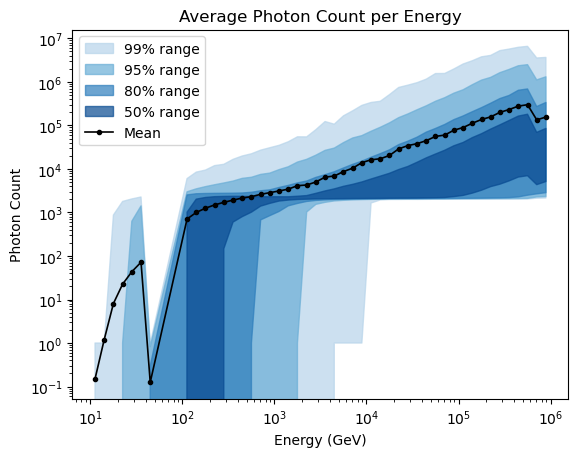

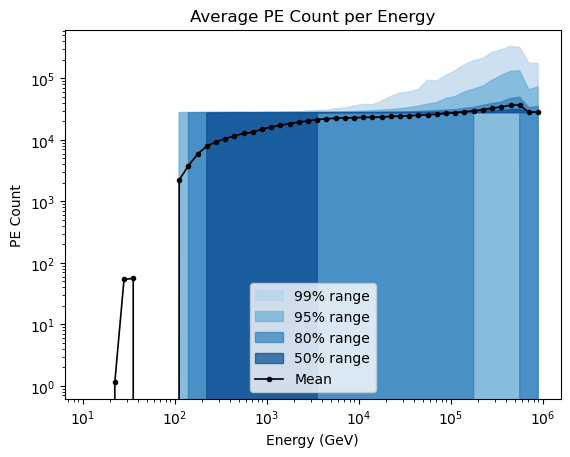

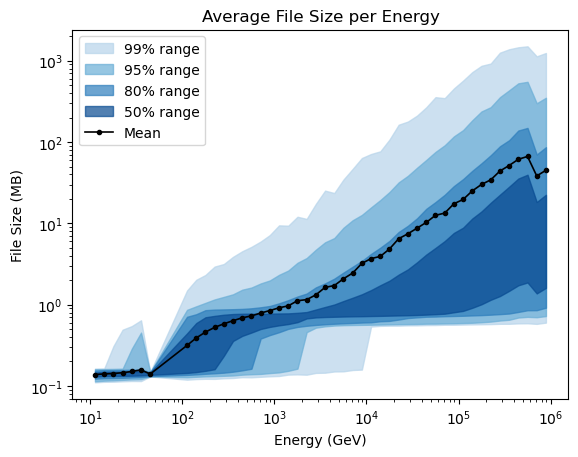

12.897803367917 TB 4304.663145085815 photon per MB


In [2]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
N_BOOTSTRAP = 1000
CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence
def bootstrap_trigger_rate(max_pe_in_bin, threshold, n_boot=N_BOOTSTRAP):
    alpha_ci = 1.0 - CI_LEVEL
    lo_pct = 100 * alpha_ci / 2
    hi_pct = 100 * (1 - alpha_ci / 2)
    n = len(max_pe_in_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    observed_rate = np.sum(max_pe_in_bin >= threshold) / n
    boot_rates = np.empty(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(max_pe_in_bin, size=n, replace=True)
        boot_rates[b] = np.sum(sample >= threshold) / n
    ci_low = np.percentile(boot_rates, lo_pct)
    ci_high = np.percentile(boot_rates, hi_pct)
    return observed_rate, ci_low, ci_high

import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"])
X = np.array(df["tel_x"])
Z = np.array(df["tel_z"])
H = np.array(df["height"])
Zenith = np.array(df["zen"])
Azimuth = np.array(df["az"])
Max_PE = np.array(df["max_pe"])
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"])
Avg_PE = np.array(df["avg_pe"])
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"])
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth)
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
x_mag = np.array(df["correction_x_m"])
y_mag = np.array(df["correction_y_m"])
file_size = np.array(df["file_size_MB"])
photon_count = np.array(df["cph_photon_count"])
max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))

File = []
Photon = []
PE = []

File_low, File_high = [], []
Photon_low, Photon_high = [], []
PE_low, PE_high = [], []

Total_FIle_Size = np.nansum(file_size)/1000 #MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 99]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}

for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Total_PE[mask])
    File.append(f)
    Photon.append(p)
    PE.append(pe)

    # 99% range (legacy)
    File_low.append(np.nanpercentile(file_size[mask], 0.5))
    File_high.append(np.nanpercentile(file_size[mask], 99.5))
    Photon_low.append(np.nanpercentile(photon_count[mask], 0.5))
    Photon_high.append(np.nanpercentile(photon_count[mask], 99.5))
    PE_low.append(np.nanpercentile(Total_PE[mask], 0.5))
    PE_high.append(np.nanpercentile(Total_PE[mask], 99.5))

    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Total_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Total_PE[mask], hi_p))

File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)

File_low, File_high     = np.array(File_low),   np.array(File_high)
Photon_low, Photon_high = np.array(Photon_low), np.array(Photon_high)
PE_low, PE_high         = np.array(PE_low),     np.array(PE_high)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))


def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count per Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "PE Count", "Average PE Count per Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size per Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


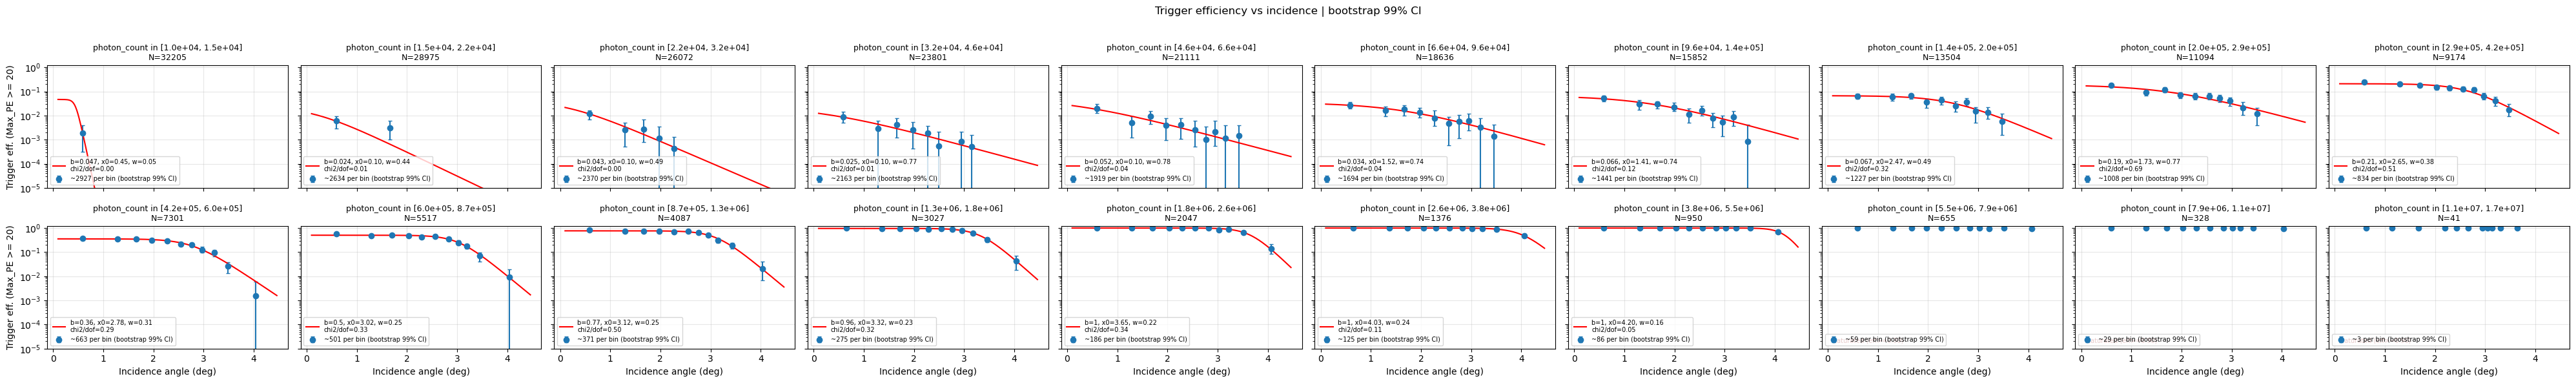

Skipped saturated bins (eff ~ 1 across incidence):
  pc_mean=6.708e+06, N=655
  pc_mean=9.695e+06, N=328
  pc_mean=1.401e+07, N=41
PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS
Fit equation: eff(x) = b / (1 + exp((x - x0) / w))
Error bars:   bootstrap 99% CI (N_boot=200)
--------------------------------------------------------------------------------
     pc_mean          b         ±b         x0        ±x0          w         ±w   chi2/dof     minN
--------------------------------------------------------------------------------
   1.282e+04     0.0441    5.4e+11      0.407    5.9e+11      0.046    1.6e+09       0.00     2851
   1.853e+04     0.0241        2.9      0.100         76      0.434        7.2       0.01     2554
   2.678e+04     0.0434        1.9      0.100         32      0.484        3.4       0.01     2288
   3.871e+04     0.0216       0.38      0.297         23      0.739          4       0.01     2092
   5.594e+04     0.0536       0.57      0.100         14      0.766          

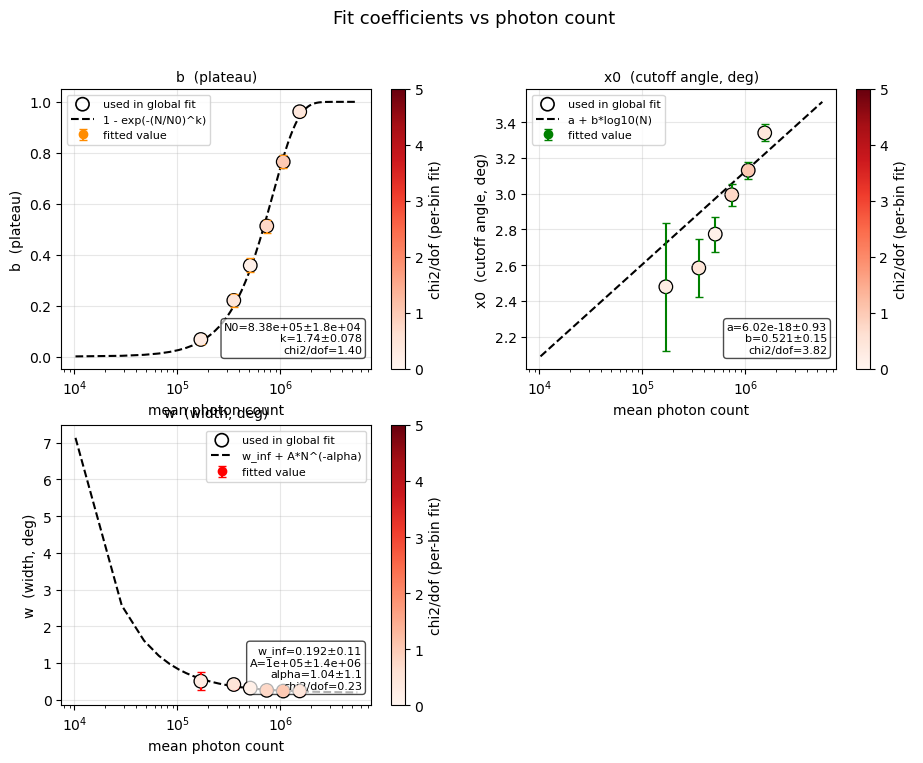


PHYSICAL MODEL FITS (coefficient vs photon count N)

--- Model for parameter 'x0' ---
Equation:  x0(N) = a + b * log10(N)
             a = 6.015e-18 ± 0.93
             b = 0.521 ± 0.15
      chi2/dof = 3.824

--- Model for parameter 'b' ---
Equation:  b(N)  = 1 - exp(-(N/N0)^k)
            N0 = 8.381e+05 ± 1.8e+04
             k = 1.743 ± 0.078
      chi2/dof = 1.402

--- Model for parameter 'w' ---
Equation:  w(N)  = w_inf + A * N**(-alpha)
         w_inf = 0.1925 ± 0.11
             A = 1e+05 ± 1.4e+06
         alpha = 1.037 ± 1.1
      chi2/dof = 0.233


In [3]:
#Fitting Model
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize

# --- User settings ---
PE_THRESHOLD = 20
n_photon_bins = 20
n_inc_bins = 10
ncols = 10
BIAS_QUANTILE = 0.1 #bias toward high incidence value
MIN_EVENTS_PER_INC_BIN = 2
MAX_CHI2_DOF = 5.0
MAX_X0_ERR_DEG = 0.5
MAX_W_ERR_DEG = 0.5
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.0001
W_ERR_FLOOR = 0.01
MIN_PARAM_ERR = 1e-4
SATURATION_EFF = 0.9
B_MIN_SIGNIFICANCE = 0.09
W_MIN_BOUND = 1e-3
B_SATURATION_MAX = 1
X0_MODEL = "log"  # options: "softplus", "log"

N_BOOTSTRAP = 200
CI_LEVEL = 99.0  # percent
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0  # 0.5 for 99%

# ---- bootstrap helper ----
def bootstrap_eff_ci(trig_bin, n_boot=N_BOOTSTRAP, ci_alpha=CI_ALPHA):
    """
    trig_bin: 1D array of 0/1 for events in one incidence bin.
    Returns (eff, err_lo, err_hi) where err_lo/hi are half-CI widths
    suitable for asymmetric errorbar.
    """
    n = len(trig_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    eff = trig_bin.mean()
    boot_effs = np.array([
        np.random.choice(trig_bin, size=n, replace=True).mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_effs, ci_alpha)
    hi = np.percentile(boot_effs, 100.0 - ci_alpha)
    # symmetric error for fitting: use half-width of CI
    err = (hi - lo) / 2.0
    err = max(err, EFF_ERR_FLOOR)
    return eff, lo, hi, err

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE > 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[pe >= PE_THRESHOLD]
pc_edges = np.logspace(min(np.log10(pc_for_edges)), max(np.log10(pc_for_edges)),n_photon_bins + 1)#np.unique(np.quantile(pc_for_edges, np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1

def logistic_cutoff(x, b, x0, w):
    exponent = np.clip((x - x0) / w, -500, 500)
    return b / (1.0 + np.exp(exponent))


# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(inc_slice, trig_slice, inc_edges):
    """
    For each incidence bin defined by inc_edges, bootstrap the efficiency.
    Returns: eff, err_sym, err_lo, err_hi, total arrays (one per bin).
    """
    n_bins = len(inc_edges) - 1
    eff_arr    = np.full(n_bins, np.nan)
    err_arr    = np.full(n_bins, np.nan)
    err_lo_arr = np.full(n_bins, np.nan)
    err_hi_arr = np.full(n_bins, np.nan)
    total_arr  = np.zeros(n_bins, dtype=int)

    for k in range(n_bins):
        in_bin = (inc_slice >= inc_edges[k]) & (inc_slice < inc_edges[k + 1])
        trig_bin = trig_slice[in_bin]
        total_arr[k] = len(trig_bin)
        if len(trig_bin) == 0:
            continue
        eff, lo, hi, err = bootstrap_eff_ci(trig_bin)
        eff_arr[k]    = eff
        err_lo_arr[k] = eff - lo   # distance below
        err_hi_arr[k] = hi - eff   # distance above
        err_arr[k]    = err

    return eff_arr, err_arr, err_lo_arr, err_hi_arr, total_arr

# ======================================================================
# PLOT: trigger efficiency per photon-count bin
# ======================================================================
nrows = int(np.ceil(n_photon_bins / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()
x_fit = np.linspace(inc.min(), inc.max(), 200)

for i in range(n_photon_bins):
    ax = axes[i]
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    n_sub = sub.sum()

    if n_sub == 0:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN=0")
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_threshold = np.quantile(inc_sub, BIAS_QUANTILE)
    inc_upper = inc_sub[inc_sub >= inc_threshold]
    if len(inc_upper) >= n_inc_bins:
        inc_edges_upper = np.unique(
            np.quantile(inc_upper, np.linspace(0, 1, n_inc_bins + 1))
        )
        inc_edges = np.unique(np.concatenate([[inc_sub.min()], inc_edges_upper]))
    else:
        inc_edges = np.unique(
            np.quantile(inc_sub, np.linspace(0, 1, n_inc_bins + 1))
        )

    if len(inc_edges) < 3:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
        ax.text(0.5, 0.5, "insufficient bins", transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='red')
        continue

    n_bins_actual = len(inc_edges) - 1
    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    # asymmetric error bars from bootstrap CI
    yerr_asym = np.array([
        np.where(np.isfinite(err_lo), err_lo, 0),
        np.where(np.isfinite(err_hi), err_hi, 0)
    ])

    ax.errorbar(inc_centers, eff, yerr=yerr_asym, fmt='o', capsize=2,
                label=f"~{n_sub // n_bins_actual} per bin (bootstrap {CI_LEVEL:.0f}% CI)")

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))

    good = np.isfinite(eff) & (total > 0)
    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0

    if saturated:
        ax.text(0.05, 0.05, f"saturated (eff>={SATURATION_EFF:.2f})",
                transform=ax.transAxes, fontsize=7, color='darkred')
    elif good.sum() >= 4 and min_total >= MIN_EVENTS_PER_INC_BIN:
        xd = inc_centers[good]
        yd = eff[good]
        sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

        inc_range = inc_edges[-1] - inc_edges[0]
        b0 = min(max(np.nanmax(yd), 0.05), 1.0)
        x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
        w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
        p0 = [b0, x0_0, w0]
        bounds = (
            [0.0, inc_edges[0], 1e-3],
            [1.05, inc_edges[-1], 0.4 * inc_range],
        )

        try:
            popt, _ = curve_fit(
                logistic_cutoff, xd, yd, p0=p0, sigma=sd,
                absolute_sigma=True, bounds=bounds, maxfev=20000
            )
            y_model = logistic_cutoff(xd, *popt)
            chi2 = np.sum(((yd - y_model) / sd) ** 2)
            dof = len(xd) - 3
            chi2_dof = chi2 / dof if dof > 0 else np.nan

            ax.plot(x_fit, logistic_cutoff(x_fit, *popt), 'r-', lw=1.5,
                    label=(f"b={popt[0]:.2g}, x0={popt[1]:.2f}, "
                           f"w={popt[2]:.2f}\nchi2/dof={chi2_dof:.2f}"))
        except Exception:
            ax.text(0.05, 0.05, "fit failed", transform=ax.transAxes,
                    fontsize=8, color='red')
    else:
        ax.text(0.05, 0.05, f"low stats (min N={min_total})",
                transform=ax.transAxes, fontsize=7, color='darkred')

    ax.legend(fontsize=7, loc='lower left')
    ax.set_ylim(1e-5, 1.2)
    ax.set_yscale("log")
    ax.set_title(f"photon_count in [{pc_lo:.1e}, {pc_hi:.1e}]\nN={n_sub}", fontsize=9)
    ax.grid(alpha=0.3)

for j in range(n_photon_bins, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_photon_bins]:
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("Incidence angle (deg)")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")

fig.suptitle(f"Trigger efficiency vs incidence | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ======================================================================
# PER-BIN FIT LOOP
# ======================================================================
pc_means, x0_vals, x0_errs = [], [], []
b_vals, b_errs = [], []
w_vals, w_errs = [], []
chi2_vals = []
min_counts = []
mean_counts = []
saturated_bins = []
saturated_ranges = []

for i in range(n_photon_bins):
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    if sub.sum() == 0:
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_edges = np.unique(
        np.quantile(inc_sub, np.linspace(0, 1, n_inc_bins + 1))
    )
    if len(inc_edges) < 3:
        continue

    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    inc_range = inc_edges[-1] - inc_edges[0]

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    eff_valid = eff[np.isfinite(eff)]
    if eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF):
        saturated_bins.append((0.5 * (pc_lo + pc_hi), int(sub.sum())))
        saturated_ranges.append((pc_lo, pc_hi))
        continue

    good = np.isfinite(eff) & (total > 0)
    if good.sum() < 4:
        continue

    xd = inc_centers[good]
    yd = eff[good]
    sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0
    mean_total = float(np.mean(total[total > 0])) if np.any(total > 0) else 0.0

    b0 = min(max(np.nanmax(yd), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
    w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
    p0 = [b0, x0_0, w0]
    bounds = (
        [0.0, inc_edges[0], 1e-3],
        [1.05, inc_edges[-1], 0.4 * inc_range],
    )

    try:
        popt, pcov = curve_fit(
            logistic_cutoff, xd, yd, p0=p0, sigma=sd,
            absolute_sigma=True, bounds=bounds, maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
        y_model = logistic_cutoff(xd, *popt)
        chi2 = np.sum(((yd - y_model) / sd) ** 2)
        dof = len(xd) - 3
        chi2_dof = chi2 / dof if dof > 0 else np.nan

        pc_means.append(0.5 * (pc_lo + pc_hi))
        b_vals.append(popt[0]);  b_errs.append(perr[0])
        x0_vals.append(popt[1]); x0_errs.append(perr[1])
        w_vals.append(popt[2]);  w_errs.append(perr[2])
        chi2_vals.append(chi2_dof)
        min_counts.append(min_total)
        mean_counts.append(mean_total)

    except Exception:
        continue

if saturated_bins:
    print("Skipped saturated bins (eff ~ 1 across incidence):")
    for pc_mean, n_sub in saturated_bins:
        print(f"  pc_mean={pc_mean:.3e}, N={n_sub}")

pc_means   = np.array(pc_means)
b_vals,  b_errs  = np.array(b_vals),  np.array(b_errs)
x0_vals, x0_errs = np.array(x0_vals), np.array(x0_errs)
w_vals,  w_errs  = np.array(w_vals),  np.array(w_errs)
chi2_vals  = np.array(chi2_vals)
min_counts = np.array(min_counts)
mean_counts = np.array(mean_counts)

# -- quality mask --
cutoff_in_range = (
    (x0_vals + 2.0 * w_vals <= inc.max()) &
    (x0_vals - 2.0 * w_vals >= inc.min())
)
finite_mask = (
    np.isfinite(chi2_vals) & np.isfinite(x0_errs) &
    np.isfinite(w_errs) & np.isfinite(b_errs)
)
stats_mask = min_counts >= MIN_EVENTS_PER_INC_BIN
err_mask = (
    (x0_errs < MAX_X0_ERR_DEG) & (w_errs < MAX_W_ERR_DEG) &
    (b_errs > MIN_PARAM_ERR) & (x0_errs > MIN_PARAM_ERR) & (w_errs > MIN_PARAM_ERR)
)
chi2_mask = chi2_vals < MAX_CHI2_DOF

with np.errstate(divide='ignore', invalid='ignore'):
    b_signif = np.where(b_errs > 0, b_vals / b_errs, 0.0)
b_signif_mask = b_signif >= B_MIN_SIGNIFICANCE

w_bound_mask = w_vals > W_MIN_BOUND * 1.05
b_saturation_mask = b_vals < B_SATURATION_MAX

quality_mask = (
    finite_mask & stats_mask & err_mask &
    chi2_mask & cutoff_in_range & b_signif_mask &
    w_bound_mask & b_saturation_mask
)

# -- diagnostics print --
print("=" * 80)
print("PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS")
print("=" * 80)
print("Fit equation: eff(x) = b / (1 + exp((x - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'pc_mean':>12} {'b':>10} {'±b':>10} {'x0':>10} {'±x0':>10} "
      f"{'w':>10} {'±w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(pc_means)):
    print(f"{pc_means[i]:12.3e} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:10.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(pc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)

dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'pc_mean':>12} {'b/σ_b':>8} {'chi2/dof':>10} {'minN':>8}  reasons")
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:     reasons.append("nonfinite")
        if not stats_mask[i]:      reasons.append(f"minN<{MIN_EVENTS_PER_INC_BIN}")
        if not err_mask[i]:        reasons.append("err-cut")
        if not chi2_mask[i]:       reasons.append(f"chi2>{MAX_CHI2_DOF}")
        if not cutoff_in_range[i]: reasons.append("x0 out of range")
        if not b_signif_mask[i]:   reasons.append(f"b/σ_b<{B_MIN_SIGNIFICANCE}")
        if not b_saturation_mask[i]: reasons.append(f"b>={B_SATURATION_MAX}")
        if not w_bound_mask[i]:      reasons.append(f"w<={W_MIN_BOUND:g}")
        bs = b_signif[i] if np.isfinite(b_signif[i]) else 0.0
        print(f"{pc_means[i]:12.3e} {bs:8.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

# -- physical models --
def x0_softplus(N, x0_lo, Nt, s, p):
    N = np.maximum(N, 1e-12)
    Nt = np.maximum(Nt, 1e-12)
    return x0_lo + s * np.log1p((N / Nt) ** p)
    
def x0_log(N, a, b_coef):
    return a + b_coef * np.log10(N)

x0_model_cfg = {
    "softplus": {
        "fn": x0_softplus,
        "p0": [3.0, 1e6, 0.5, 2.0],
        "bounds": ([2.0, 1e5, 0.0, 0.5], [5.0, 1e7, 5.0, 10.0]),
        "label": r"x0_lo + s*log1p((N/Nt)^p)",
        "param_names": ["x0_lo", "Nt", "s", "p"],
    },
    "log": {
        "fn": x0_log,
        "p0": [3.0, 0.5],
        "bounds": ([0.0, -5.0], [10.0, 5.0]),
        "label": r"a + b*log10(N)",
        "param_names": ["a", "b"],
    },
}

if X0_MODEL not in x0_model_cfg:
    raise ValueError(f"Unknown X0_MODEL='{X0_MODEL}'. Use 'softplus' or 'log'.")
x0_model = x0_model_cfg[X0_MODEL]
x0_model_fn = x0_model["fn"]

def plateau_model(N, N0, k):
    N = np.maximum(N, 1e-12)
    return 1.0 - np.exp(-(N / N0) ** k)

def w_model(N, w_inf, A, alpha):
    N = np.maximum(N, 1e-12)
    return w_inf + A * N**(-alpha)

results = {}

def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof

ok_x0 = quality_mask & np.isfinite(x0_errs) #old
#ok_x0 = quality_mask & np.isfinite(x0_errs) & (x0_errs < 0.3)  # was just isfinite

try:
    popt, perr, pcov, c2 = fit_model(
        x0_model_fn, pc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=x0_model["p0"],
        bounds=x0_model["bounds"],
    )
    results['x0'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"x0 model fit failed: {e}")

ok_b = quality_mask & (b_vals < B_SATURATION_MAX) & np.isfinite(b_errs) #old
"""ok_b = (
    quality_mask &
    (b_vals < B_SATURATION_MAX) &
    np.isfinite(b_errs) &
    (b_errs < 0.1) &          # tighter error cut
    (b_vals / b_errs > 3.0)   # stricter significance (was 0.09)
)"""
try:
    popt, perr, pcov, c2 = fit_model(
        plateau_model, pc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=[np.median(pc_means[ok_b]), 1.0],
        bounds=([pc_means.min() * 0.1, 0.1], [pc_means.max() * 10.0, 10.0])
    )
    results['b'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"b model fit failed: {e}")

ok_w = quality_mask & np.isfinite(w_errs) & (w_vals > 0)
try:
    popt, perr, pcov, c2 = fit_model(
        w_model, pc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=[0.15, 50.0, 0.5],
        bounds=([0.0, 0.0, 0.1], [1.0, 1e5, 1.5])
    )
    results['w'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"w model fit failed: {e}")

# -- comparison plot --
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
N_smooth = np.linspace(pc_means.min() * 0.8, pc_means.max() * 1.2, 300)

labels      = ['b  (plateau)', 'x0  (cutoff angle, deg)', 'w  (width, deg)']
yvals       = [b_vals, x0_vals, w_vals]
yerrs       = [b_errs, x0_errs, w_errs]
colors      = ['darkorange', 'green', 'red']
model_keys  = ['b', 'x0', 'w']
model_fns   = [plateau_model, x0_model_fn, w_model]
model_labels = {
    'x0': x0_model["label"],
    'b':  r"1 - exp(-(N/N0)^k)",
    'w':  r"w_inf + A*N^(-alpha)",
}
param_names = {
    'x0': x0_model["param_names"],
    'b':  ['N0', 'k'],
    'w':  ['w_inf', 'A', 'alpha'],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(pc_means[qm], yv[qm], yerr=ye[qm], fmt='o', color=col,
                capsize=3, label='fitted value', zorder=3)
    sc = ax.scatter(pc_means[qm], yv[qm], c=chi2_vals[qm], cmap='Reds',
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label='chi2/dof (per-bin fit)')
    ax.scatter(pc_means[qm], yv[qm],
               facecolors='none', edgecolors='black', s=90,
               linewidths=1.2, label='used in global fit')

    if mkey in results:
        popt, perr, pcov, c2 = results[mkey]
        ax.plot(N_smooth, mfn(N_smooth, *popt), 'k--',
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}±{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha='right', va='bottom',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.set_xscale('log')
    ax.set_xlabel('mean photon count')
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis('off')

fig.suptitle("Fit coefficients vs photon count", fontsize=13)
#fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# -- physical model summary --
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs photon count N)")
print("=" * 80)
model_equations = {
    'x0': "x0(N) = x0_lo + s * log1p((N/Nt)^p)" if X0_MODEL == "softplus" else "x0(N) = a + b * log10(N)",
    'b':  "b(N)  = 1 - exp(-(N/N0)^k)",
    'w':  "w(N)  = w_inf + A * N**(-alpha)",
}
for key in ['x0', 'b', 'w']:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, pcov, c2 = results[key]
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} ± {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)


In [3]:
# Bootstrap global fits and combine covariance with fit covariance
from scipy.optimize import curve_fit
import numpy as np

N_BOOTSTRAP_FIT = 200
BOOTSTRAP_FIT_SEED = 12345

def _sanitize_sigma(sig, floor):
    sig = np.asarray(sig, dtype=float)
    return np.where(np.isfinite(sig) & (sig > 0), sig, floor)

def _bootstrap_fit_cov(fn, xdata, ydata, yerr, p0, bounds, n_boot, rng, floor):
    xdata = np.asarray(xdata, dtype=float)
    ydata = np.asarray(ydata, dtype=float)
    yerr = _sanitize_sigma(yerr, floor)
    n = len(xdata)
    n_params = len(p0)
    if n < n_params + 1 or n_boot < 2:
        return np.zeros((n_params, n_params)), 0
    params = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb = xdata[idx]
        yb = ydata[idx]
        sb = yerr[idx]
        try:
            popt_b, _ = curve_fit(
                fn, xb, yb, p0=p0, sigma=sb,
                absolute_sigma=True, bounds=bounds, maxfev=20000
            )
            params.append(popt_b)
        except Exception:
            continue
    if len(params) < 2:
        return np.zeros((n_params, n_params)), len(params)
    params = np.vstack(params)
    cov = np.cov(params, rowvar=False, ddof=1)
    if cov.shape != (n_params, n_params):
        cov = np.zeros((n_params, n_params))
    return cov, len(params)

def _combine_fit_cov(key, fn, ok_mask, yvals, yerrs, bounds, floor, n_boot, rng):
    if key not in results:
        return 0
    xdata = pc_means[ok_mask]
    ydata = yvals[ok_mask]
    yerr = _sanitize_sigma(yerrs[ok_mask], floor)
    if xdata.size < 2:
        return 0
    popt, perr, pcov, c2 = results[key]
    boot_cov, boot_ok = _bootstrap_fit_cov(
        fn, xdata, ydata, yerr, popt, bounds,
        n_boot=n_boot, rng=rng, floor=floor
    )
    pcov_total = pcov + boot_cov
    perr_total = np.sqrt(np.maximum(np.diag(pcov_total), 0.0))
    results[key] = (popt, perr_total, pcov_total, c2)
    return boot_ok

rng = np.random.default_rng(BOOTSTRAP_FIT_SEED)
boot_ok = {}

if "x0" in results:
    boot_ok["x0"] = _combine_fit_cov(
        "x0", x0_model_fn, ok_x0, x0_vals, x0_errs,
        x0_model["bounds"], W_ERR_FLOOR, N_BOOTSTRAP_FIT, rng
    )
if "b" in results and pc_means.size > 0:
    b_bounds = ([pc_means.min() * 0.1, 0.1], [pc_means.max() * 10.0, 10.0])
    boot_ok["b"] = _combine_fit_cov(
        "b", plateau_model, ok_b, b_vals, b_errs,
        b_bounds, B_ERR_FLOOR, N_BOOTSTRAP_FIT, rng
    )
if "w" in results:
    boot_ok["w"] = _combine_fit_cov(
        "w", w_model, ok_w, w_vals, w_errs,
        ([0.0, 0.0, 0.1], [1.0, 1e5, 1.5]), W_ERR_FLOOR, N_BOOTSTRAP_FIT, rng
    )

print("Bootstrap on global fits combined with fit covariance:")
for key in ["x0", "b", "w"]:
    if key in boot_ok:
        print(f"  {key}: {boot_ok[key]}/{N_BOOTSTRAP_FIT} successful resamples")

Bootstrap on global fits combined with fit covariance:
  x0: 200/200 successful resamples
  b: 200/200 successful resamples
  w: 200/200 successful resamples



Global chi2 / dof = 2070.15 / 400 = 5.175


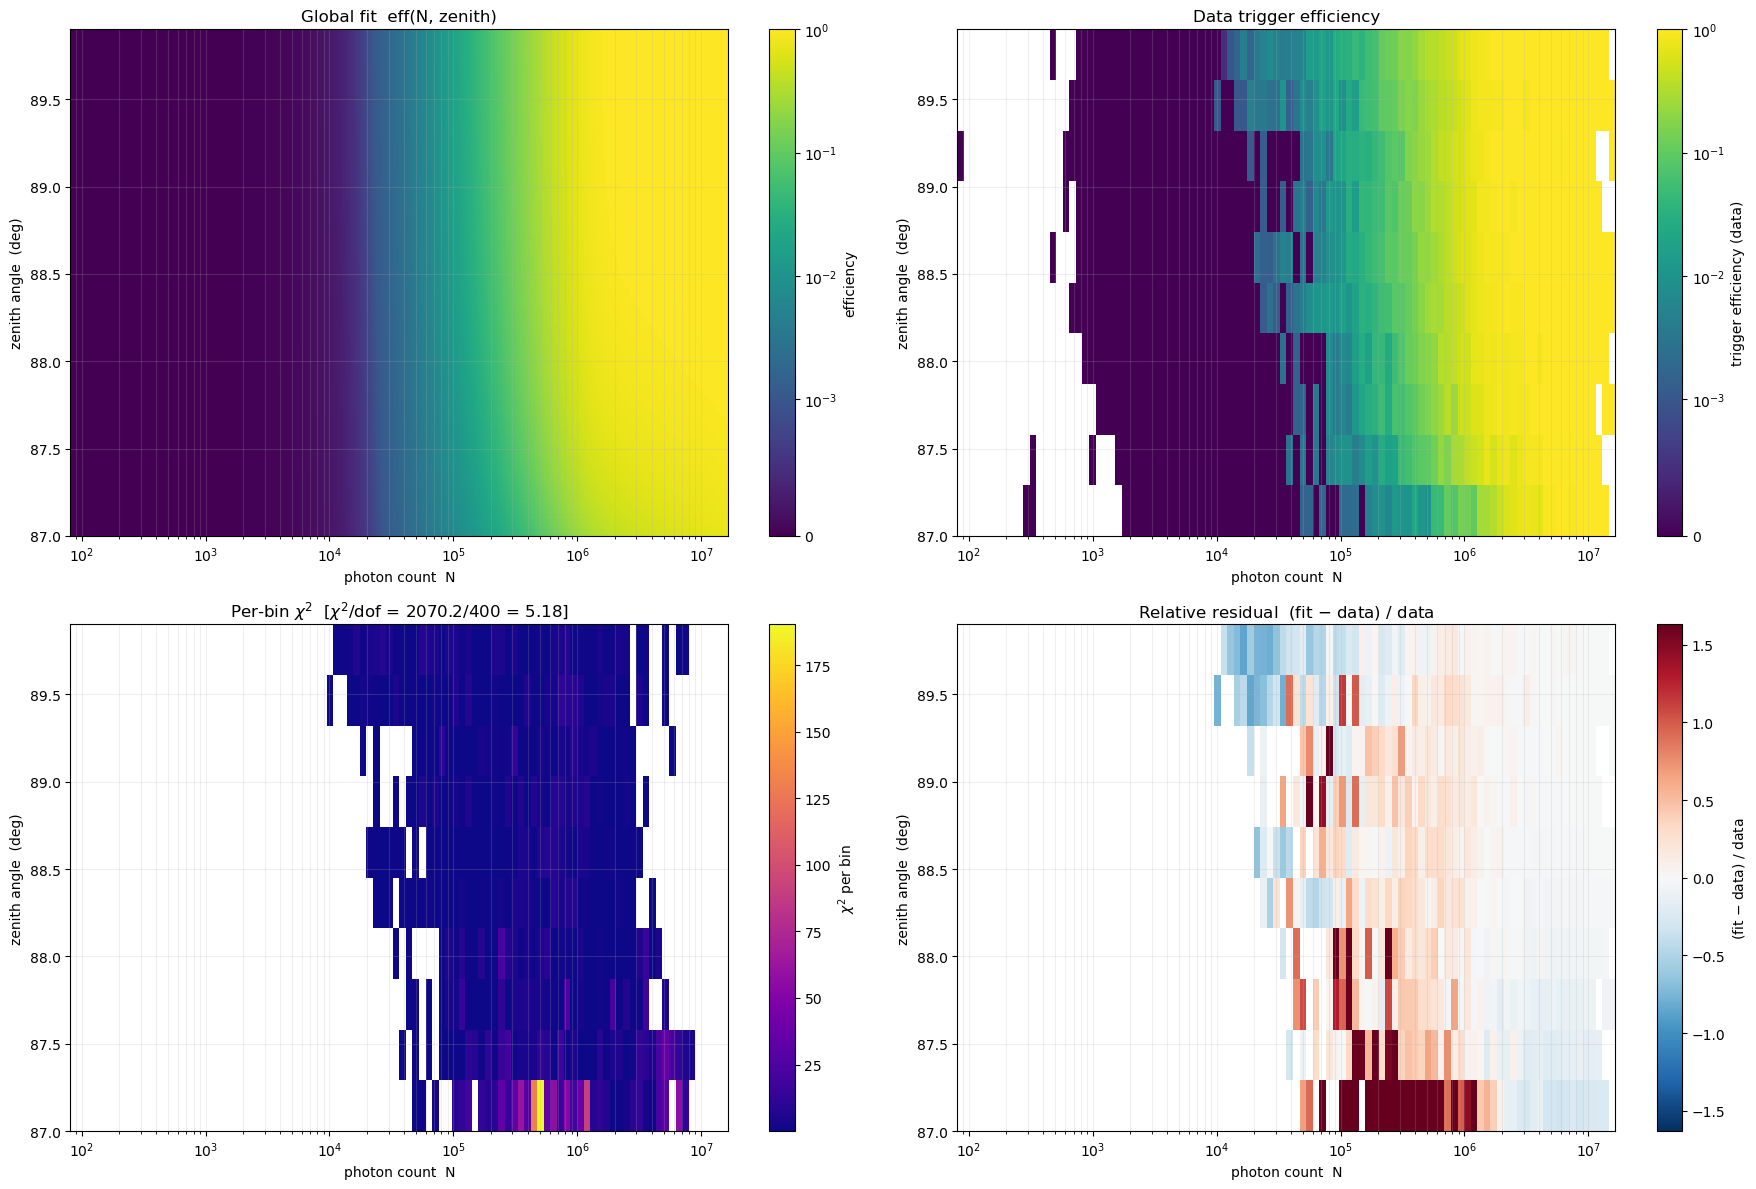

In [4]:
#Define Function:
from matplotlib.colors import SymLogNorm

b_N0, b_k          = results['b'][0];  cov_b  = results['b'][2]
w_inf, w_A, w_alpha = results['w'][0];  cov_w  = results['w'][2]

if X0_MODEL == "softplus":
    x0_lo, x0_Nt, x0_s, x0_p = results['x0'][0]; cov_x0 = results['x0'][2]
    x0_param_names = ["x0_lo", "x0_Nt", "x0_s", "x0_p"]
elif X0_MODEL == "log":
    x0_a, x0_b = results['x0'][0]; cov_x0 = results['x0'][2]
    x0_param_names = ["x0_a", "x0_b"]
else:
    raise ValueError(f"Unknown X0_MODEL='{X0_MODEL}'. Use 'softplus' or 'log'.")

b_param_names = ["b_N0", "b_k"]
w_param_names = ["w_inf", "w_A", "w_alpha"]
PARAM_ORDER = b_param_names + x0_param_names + w_param_names
N_PARAMS = len(PARAM_ORDER)

cov_b = np.asarray(cov_b, dtype=float)
cov_x0 = np.asarray(cov_x0, dtype=float)
cov_w = np.asarray(cov_w, dtype=float)

def _build_cov_full(cov_b, cov_x0, cov_w):
    n_b = cov_b.shape[0]
    n_x0 = cov_x0.shape[0]
    n_w = cov_w.shape[0]
    cov_full = np.zeros((n_b + n_x0 + n_w, n_b + n_x0 + n_w))
    cov_full[:n_b, :n_b] = cov_b
    cov_full[n_b:n_b + n_x0, n_b:n_b + n_x0] = cov_x0
    cov_full[n_b + n_x0:, n_b + n_x0:] = cov_w
    return cov_full

COV_FULL = _build_cov_full(cov_b, cov_x0, cov_w)

def _sigma_from_grad(grad):
    grad = np.asarray(grad, dtype=float)
    var = np.einsum('...i,ij,...j->...', grad, COV_FULL, grad)
    return np.sqrt(np.maximum(var, 0.0))

if saturated_ranges:
    sat_pc_min = min(r[0] for r in saturated_ranges)
else:
    sat_pc_min = np.inf


def optical_efficiency(photon_counts, incidence):
    N = np.asarray(photon_counts, dtype=float)
    x = np.asarray(incidence,     dtype=float)
    N, x = np.broadcast_arrays(N, x)
    b  = 1.0 - np.exp(-(N / b_N0) ** b_k)
    if X0_MODEL == "softplus":
        x0 = x0_lo + x0_s * np.log1p((N / x0_Nt) ** x0_p)
    else:
        N_safe = np.maximum(N, 1e-12)
        x0 = x0_a + x0_b * np.log10(N_safe)
    w  = w_inf + w_A * N**(-w_alpha)
    z  = np.clip((x - x0) / w, -50.0, 50.0)
    return np.clip(b / (1.0 + np.exp(z)), 0.0, 1.0)


def optical_efficiency_gradients(photon_counts, incidence):
    N = np.asarray(photon_counts, dtype=float)
    x = np.asarray(incidence,     dtype=float)
    N, x = np.broadcast_arrays(N, x)
    N_safe = np.maximum(N, 1e-12)

    exp_b  = np.exp(-(N_safe / b_N0) ** b_k)
    b      = 1.0 - exp_b

    if X0_MODEL == "softplus":
        u   = (N_safe / x0_Nt) ** x0_p
        x0  = x0_lo + x0_s * np.log1p(u)
    else:
        x0  = x0_a + x0_b * np.log10(N_safe)

    w   = w_inf + w_A * N_safe ** (-w_alpha)
    z   = np.clip((x - x0) / w, -50.0, 50.0)
    sig = 1.0 / (1.0 + np.exp(z))
    eff = np.clip(b * sig, 0.0, 1.0)

    d_sig_dz = -np.exp(z) * sig**2

    t_b   = (N_safe / b_N0) ** b_k
    db_dN0_param = -exp_b * (b_k * t_b / b_N0)
    db_dk  = exp_b * t_b * np.log(N_safe / b_N0)

    d_eff_dN0 = sig * db_dN0_param
    d_eff_dk  = sig * db_dk

    dz_dx0 = -1.0 / w
    base_x0 = b * d_sig_dz * dz_dx0

    if X0_MODEL == "softplus":
        d_eff_dx0_lo = base_x0 * 1.0
        d_eff_dx0_s  = base_x0 * np.log1p(u)
        d_eff_dx0_Nt = base_x0 * x0_s * (u / (1.0 + u)) * (-x0_p / x0_Nt)
        d_eff_dx0_p  = base_x0 * x0_s * (u / (1.0 + u)) * np.log(N_safe / x0_Nt)
        grad_x0 = np.stack([d_eff_dx0_lo, d_eff_dx0_Nt,
                             d_eff_dx0_s,  d_eff_dx0_p], axis=-1)
    else:
        d_eff_dx0_a  = base_x0 * 1.0
        d_eff_dx0_b  = base_x0 * np.log10(N_safe)
        grad_x0 = np.stack([d_eff_dx0_a, d_eff_dx0_b], axis=-1)

    dz_dw  = -(x - x0) / w**2
    base_w = b * d_sig_dz * dz_dw

    d_eff_dwinf  = base_w * 1.0
    d_eff_dA     = base_w * N_safe ** (-w_alpha)
    d_eff_dalpha = base_w * (-w_A) * N_safe**(-w_alpha) * np.log(N_safe)

    grad_b = np.stack([d_eff_dN0, d_eff_dk], axis=-1)
    grad_w = np.stack([d_eff_dwinf, d_eff_dA, d_eff_dalpha], axis=-1)
    grad_full = np.concatenate([grad_b, grad_x0, grad_w], axis=-1)

    return eff, grad_full


def optical_efficiency_with_uncertainty(photon_counts, incidence):
    eff, grad = optical_efficiency_gradients(photon_counts, incidence)
    sigma_eff = _sigma_from_grad(grad)
    return eff, sigma_eff


"""def eff_vs_zenith_vectorized(N_arr, theta_z_arr, psi_deg, phi_max_deg=3.0, n_phi=100):
    #Fully vectorized azimuth-averaged efficiency.

    #Parameters
    #----------
    #N_arr       : (n_N,)   photon counts
    #theta_z_arr : (n_zen,) zenith angles in degrees
    #psi_deg     : float    muon incidence angle in degrees

    #Returns
    #-------
    #EFF : (n_zen, n_N) azimuth-averaged efficiency
    phi     = np.linspace(0.0, np.radians(phi_max_deg), n_phi)          # (n_phi,)
    theta_z = np.radians(np.asarray(theta_z_arr, dtype=float))          # (n_zen,)
    psi     = np.radians(float(psi_deg))

    # cos_theta: (n_zen, n_phi)
    cos_theta = (
        np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
        + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_theta))                         # (n_zen, n_phi)

    # broadcast to (n_N, n_zen, n_phi)
    N_3d     = np.asarray(N_arr, dtype=float)[:, np.newaxis, np.newaxis]
    theta_3d = theta_inc[np.newaxis, :, :]                              # (1, n_zen, n_phi)

    eff_vals = optical_efficiency(N_3d, theta_3d)                        # (n_N, n_zen, n_phi)

    # integrate over phi, normalize -> (n_N, n_zen)
    avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])

    return avg.T  """


def eff_vs_zenith_vectorized(N_arr, theta_z_arr, psi_deg,
                              phi_max_deg=3.0, n_phi=100,
                              paired=False):
    """
    Azimuth-averaged efficiency.

    Parameters
    ----------
    N_arr       : (n_N,)   photon counts
    theta_z_arr : (n_zen,) zenith angles in degrees
                 OR (n_N,) if paired=True
    psi_deg     : float    muon incidence angle in degrees
    paired      : bool
                 False -> grid output (n_zen, n_N)  [original behaviour]
                 True  -> element-wise, N_arr and theta_z_arr must be same
                          length, output (n_N,)

    Returns
    -------
    EFF : (n_zen, n_N)  if paired=False
          (n_N,)        if paired=True
    """
    phi     = np.linspace(0.0, np.radians(phi_max_deg), n_phi)   # (n_phi,)
    theta_z = np.radians(np.asarray(theta_z_arr, dtype=float))    # (n_zen,) or (n_N,)
    N_arr   = np.asarray(N_arr, dtype=float)                      # (n_N,)
    psi     = np.radians(float(psi_deg))

    if paired:
        # --- element-wise: (n_N,) × (n_N,) -> (n_N,) ----------------
        assert N_arr.shape == theta_z.shape, \
            "paired=True requires N_arr and theta_z_arr to have the same shape"

        # cos_theta: (n_N, n_phi)
        cos_theta = (
            np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
            + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
        )
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta_inc = np.degrees(np.arccos(cos_theta))              # (n_N, n_phi)

        # (n_N, n_phi)
        N_2d     = N_arr[:, np.newaxis]
        eff_vals = optical_efficiency(N_2d, theta_inc)            # (n_N, n_phi)

        avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])
        return avg                                                 # (n_N,)

    else:
        # --- grid: (n_zen,) × (n_N,) -> (n_zen, n_N) ----------------
        # cos_theta: (n_zen, n_phi)
        cos_theta = (
            np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
            + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
        )
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta_inc = np.degrees(np.arccos(cos_theta))              # (n_zen, n_phi)

        # broadcast to (n_N, n_zen, n_phi)
        N_3d     = N_arr[:, np.newaxis, np.newaxis]
        theta_3d = theta_inc[np.newaxis, :, :]

        eff_vals = optical_efficiency(N_3d, theta_3d)             # (n_N, n_zen, n_phi)

        avg = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])
        return avg.T                                               # (n_zen, n_N)


def eff_vs_zenith_with_gradients(N_arr, theta_z_arr, psi_deg,
                                 phi_max_deg=3.0, n_phi=100,
                                 paired=False):
    """
    Azimuth-averaged efficiency and gradients.
    """
    phi     = np.linspace(0.0, np.radians(phi_max_deg), n_phi)   # (n_phi,)
    theta_z = np.radians(np.asarray(theta_z_arr, dtype=float))    # (n_zen,) or (n_N,)
    N_arr   = np.asarray(N_arr, dtype=float)                      # (n_N,)
    psi     = np.radians(float(psi_deg))

    if paired:
        assert N_arr.shape == theta_z.shape, \
            "paired=True requires N_arr and theta_z_arr to have the same shape"

        cos_theta = (
            np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
            + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
        )
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta_inc = np.degrees(np.arccos(cos_theta))              # (n_N, n_phi)

        N_2d     = N_arr[:, np.newaxis]
        eff_vals, grad_vals = optical_efficiency_gradients(N_2d, theta_inc)

        avg_eff = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])
        avg_grad = np.trapezoid(grad_vals, phi, axis=-2) / (phi[-1] - phi[0])
        return avg_eff, avg_grad                                   # (n_N,), (n_N, n_params)

    else:
        cos_theta = (
            np.cos(psi) * np.cos(theta_z)[:, np.newaxis]
            + np.sin(psi) * np.sin(theta_z)[:, np.newaxis] * np.cos(phi)[np.newaxis, :]
        )
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta_inc = np.degrees(np.arccos(cos_theta))              # (n_zen, n_phi)

        N_3d     = N_arr[:, np.newaxis, np.newaxis]
        theta_3d = theta_inc[np.newaxis, :, :]

        eff_vals, grad_vals = optical_efficiency_gradients(N_3d, theta_3d)

        avg_eff = np.trapezoid(eff_vals, phi, axis=-1) / (phi[-1] - phi[0])
        avg_grad = np.trapezoid(grad_vals, phi, axis=2) / (phi[-1] - phi[0])

        return avg_eff.T, np.transpose(avg_grad, (1, 0, 2))        # (n_zen, n_N), (n_zen, n_N, n_params)


from scipy.interpolate import LinearNDInterpolator

# =========================================================================
# Grids and edges  (defined once, reused everywhere)
# =========================================================================
N_grid    = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 400)
zen_grid  = np.linspace(Zenith.min(), Zenith.max(), 100)

N_edges   = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 101)
zen_edges = np.linspace(Zenith.min(), Zenith.max(), 11)

N_centers   = 0.5 * (N_edges[:-1]  + N_edges[1:])
zen_centers = 0.5 * (zen_edges[:-1] + zen_edges[1:])

# =========================================================================
# Efficiency maps
# =========================================================================
EFF = eff_vs_zenith_vectorized(N_grid, zen_grid, psi_deg=90)
EFF_fit_bins = eff_vs_zenith_vectorized(N_centers, zen_centers, psi_deg=90)
eff_fit = EFF_fit_bins.T

NN, ZZ = np.meshgrid(N_grid, zen_grid)

# =========================================================================
# 2-D histograms
# =========================================================================
Zenith_masked = Zenith[mask]
trig_mask     = trig == 1

total_2d,     _, _ = np.histogram2d(pc,            Zenith_masked,            bins=[N_edges, zen_edges])
triggered_2d, _, _ = np.histogram2d(pc[trig_mask], Zenith_masked[trig_mask], bins=[N_edges, zen_edges])

with np.errstate(divide='ignore', invalid='ignore'):
    eff_data = np.where(total_2d > 0, triggered_2d / total_2d, np.nan)

# =========================================================================
# Chi-square calculation
# =========================================================================
with np.errstate(divide='ignore', invalid='ignore'):
    sigma_data = np.where(
        total_2d > 0,
        np.sqrt(eff_data * (1.0 - eff_data) / total_2d),
        np.nan,
    )
    chi2_2d = np.where(
        (sigma_data > 0)
        & np.isfinite(eff_data)
        & (total_2d >= MIN_EVENTS_PER_INC_BIN),
        ((eff_data - eff_fit) / sigma_data) ** 2,
        np.nan,
    )

n_free_params = 3
valid_mask    = np.isfinite(chi2_2d)
dof           = valid_mask.sum() - n_free_params
chi2_total    = np.nansum(chi2_2d)
chi2_per_dof  = chi2_total / dof if dof > 0 else np.nan

print(f"\nGlobal chi2 / dof = {chi2_total:.2f} / {dof} = {chi2_per_dof:.3f}")

# =========================================================================
# Figure — 2 rows × 2 plots: fit | data | chi^2 | relative residual
# =========================================================================
norm_eff = SymLogNorm(linthresh=1e-3, linscale=1.0, vmin=0.0, vmax=1.0, base=10)

with np.errstate(divide='ignore', invalid='ignore'):
    rel_residual = np.where(
        (eff_data > 0) & np.isfinite(eff_data),
        (eff_fit - eff_data) / eff_data,
        np.nan,
    )

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- top-left: fit ---
ax = axes[0, 0]
pcm0 = ax.pcolormesh(NN, ZZ, EFF, shading='auto', cmap='viridis', norm=norm_eff)
ax.set_xscale('log')
ax.set_xlim(N_grid.min(), N_grid.max())
ax.set_ylim(Zenith.min(), Zenith.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title('Global fit  eff(N, zenith)')
fig.colorbar(pcm0, ax=ax).set_label('efficiency')
ax.grid(alpha=0.2, which='both')

# --- top-right: data ---
ax = axes[0, 1]
pcm1 = ax.pcolormesh(
    N_edges, zen_edges, eff_data.T,
    shading='flat', cmap='viridis', norm=norm_eff,
)
ax.set_xscale('log')
ax.set_xlim(N_edges.min(), N_edges.max())
ax.set_ylim(Zenith.min(), Zenith.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title('Data trigger efficiency')
fig.colorbar(pcm1, ax=ax).set_label('trigger efficiency (data)')
ax.grid(alpha=0.2, which='both')

# --- bottom-left: chi^2 ---
ax = axes[1, 0]
pcm2 = ax.pcolormesh(
    N_edges, zen_edges, chi2_2d.T,
    shading='flat', cmap='plasma',
    #norm=SymLogNorm(linthresh=0.5, linscale=0.5, vmin=0.0, vmax=None, base=10),
)
fig.colorbar(pcm2, ax=ax).set_label(r'$\chi^2$ per bin')
ax.set_xscale('log')
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title(
    f'Per-bin $\\chi^2$  '
    f'[$\\chi^2$/dof = {chi2_total:.1f}/{dof} = {chi2_per_dof:.2f}]',
)
ax.grid(alpha=0.2, which='both')

# --- bottom-right: relative residual (fit - data) / data ---
ax = axes[1, 1]
res_abs_max = np.nanpercentile(np.abs(rel_residual), 95)  # robust color scale
pcm3 = ax.pcolormesh(
    N_edges, zen_edges, rel_residual.T,
    shading='flat', cmap='RdBu_r',
    vmin=-res_abs_max, vmax=res_abs_max,
)
fig.colorbar(pcm3, ax=ax).set_label(r'(fit $-$ data) / data')
ax.set_xscale('log')
ax.set_xlim(N_edges.min(), N_edges.max())
ax.set_ylim(Zenith.min(), Zenith.max())
ax.set_xlabel('photon count  N')
ax.set_ylabel('zenith angle  (deg)')
ax.set_title('Relative residual  (fit $-$ data) / data')
ax.grid(alpha=0.2, which='both')

fig.tight_layout()
plt.show()

In [5]:
#Extrapolation and Interpolation
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt
from functools import lru_cache

@lru_cache(maxsize=None)
def _eff_cached(N_int, zenith_tuple, psi_deg, phi_max_deg, n_phi):
    pc  = np.array([N_int], dtype=float)
    zen = np.array(zenith_tuple, dtype=float)
    return eff_vs_zenith_vectorized(pc, zen, psi_deg, phi_max_deg, n_phi, paired=False)[:, 0]
    # returns (n_zen,)

@lru_cache(maxsize=None)
def _eff_grad_cached(N_int, zenith_tuple, psi_deg, phi_max_deg, n_phi):
    pc  = np.array([N_int], dtype=float)
    zen = np.array(zenith_tuple, dtype=float)
    _, grad = eff_vs_zenith_with_gradients(pc, zen, psi_deg, phi_max_deg, n_phi, paired=False)
    return grad[:, 0, :]
    # returns (n_zen, n_params)

def _bootstrap_sigma(eff_vals, reducer, n_boot=200, rng=None):
    eff_vals = np.asarray(eff_vals, dtype=float)
    if rng is None:
        rng = np.random.default_rng()
    if eff_vals.ndim == 1:
        n_pc = eff_vals.shape[0]
        if n_pc == 0:
            return np.nan
        idx = rng.integers(0, n_pc, size=(n_boot, n_pc))
        boot = eff_vals[idx]
        boot_stat = reducer(boot, axis=1)
        return np.std(boot_stat, ddof=1)
    if eff_vals.ndim == 2:
        n_zen, n_pc = eff_vals.shape
        if n_pc == 0:
            return np.full(n_zen, np.nan)
        idx = rng.integers(0, n_pc, size=(n_boot, n_pc))
        boot = eff_vals[:, idx]
        boot_stat = reducer(boot, axis=2)
        return np.std(boot_stat, axis=1, ddof=1)
    raise ValueError("eff_vals must be 1D or 2D")

# =========================================================================
# Slant depth (geometry)
# =========================================================================
def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad #detector pointing at 90 degree zenith
    beta  = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi / 2)
    alpha = np.pi - theta - beta
    s     = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf) #return in the unit of zem

OBS_HEIGHT_M  = 2944.0
EARTH_RADIUS_M = 6_371_000.0

# =========================================================================
# 3. Empirical efficiency cube on (zenith, H, E)
# =========================================================================
def efficiency_grid_H_E(E_edges, H_edges, zenith_deg,
                        Energy_GeV, H_emit, photon_count,
                        psi_deg=90.0, phi_max_deg=3.0, n_phi=20,
                        min_pts=5, reduce='mean', n_boot=200, rng=None):
    """
    Bin CORSIKA showers in (E, H), compute optical efficiency per bin.

    Returns
    -------
    EFF          : (n_zen, n_H, n_E)
    STD          : (n_zen, n_H, n_E)  scatter of per-shower eff
    COUNTS       : (n_H, n_E)
    E_cen        : (n_E,)
    H_cen        : (n_H,)
    pc_in_bin    : list[n_H][n_E] -> arrays
    GRAD         : (n_zen, n_H, n_E, n_params)
    SIG_FIT      : (n_zen, n_H, n_E)  from covariance
    SIG_SCATTER  : (n_zen, n_H, n_E)  bootstrap sigma on bin estimator
    SIG_TOTAL    : (n_zen, n_H, n_E)  combined
    """
    E_edges    = np.asarray(E_edges,    dtype=float)
    H_edges    = np.asarray(H_edges,    dtype=float)
    zenith_deg = np.atleast_1d(np.asarray(zenith_deg, dtype=float))

    Energy_GeV   = np.asarray(Energy_GeV,   dtype=float)
    H_emit       = np.asarray(H_emit,       dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)

    n_E   = len(E_edges) - 1
    n_H   = len(H_edges) - 1
    n_zen = len(zenith_deg)

    EFF          = np.full((n_zen, n_H, n_E), np.nan)
    STD          = np.full((n_zen, n_H, n_E), np.nan)
    GRAD         = np.full((n_zen, n_H, n_E, N_PARAMS), np.nan)
    SIG_SCATTER  = np.full((n_zen, n_H, n_E), np.nan)
    COUNTS       = np.zeros((n_H, n_E), dtype=int)

    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    reducer = np.mean if reduce == 'mean' else np.median
    if rng is None:
        rng = np.random.default_rng()

    # --- per (E, H) bin: collect photon counts and compute efficiencies ---
    # store raw photon counts per bin for later extrapolation use
    pc_in_bin = [[None] * n_E for _ in range(n_H)]  # [n_H][n_E] -> array of pc

    zen_tuple = tuple(zenith_deg)
    for i in range(n_E):
        in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i + 1])
        for j in range(n_H):
            mask = in_E & (H_emit >= H_edges[j]) & (H_emit < H_edges[j + 1])
            pc   = photon_count[mask]
            pc   = pc[np.isfinite(pc) & (pc > 0)]
            COUNTS[j, i] = len(pc)
            pc_in_bin[j][i] = pc

            if len(pc) < min_pts:
                continue

            eff_vals = np.array([
                _eff_cached(int(round(p)), zen_tuple, psi_deg, phi_max_deg, n_phi)
                for p in pc
            ])                        # (n_pc, n_zen)
            eff_vals = eff_vals.T     # (n_zen, n_pc)

            grad_vals = np.array([
                _eff_grad_cached(int(round(p)), zen_tuple, psi_deg, phi_max_deg, n_phi)
                for p in pc
            ])                        # (n_pc, n_zen, n_params)
            grad_vals = np.moveaxis(grad_vals, 0, 1)  # (n_zen, n_pc, n_params)

            EFF[:, j, i] = reducer(eff_vals, axis=1)
            STD[:, j, i] = np.std(eff_vals, axis=1)
            GRAD[:, j, i, :] = reducer(grad_vals, axis=1)
            SIG_SCATTER[:, j, i] = _bootstrap_sigma(eff_vals, reducer, n_boot=n_boot, rng=rng)

    SIG_FIT = _sigma_from_grad(GRAD)
    SIG_TOTAL = np.sqrt(SIG_FIT**2 + SIG_SCATTER**2)

    return EFF, STD, COUNTS, E_cen, H_cen, pc_in_bin, GRAD, SIG_FIT, SIG_SCATTER, SIG_TOTAL


# =========================================================================
# 4. Build (E, Slant) photon-count lookup table
# =========================================================================
def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                            Zenith_deg, n_slant_bins):
    """
    Bin data in (E, Slant) and store all photon counts per bin.
    Slant is computed from each shower's H and Zenith.

    Returns
    -------
    S_edges   : (n_slant+1,)
    S_cen     : (n_slant,)
    pc_ES     : list[n_E][n_S]  -> np.array of photon counts
    """
    E_edges    = np.asarray(E_edges,    dtype=float)
    H_emit     = np.asarray(H_emit,     dtype=float)
    Energy_GeV = np.asarray(Energy_GeV, dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad = np.radians(np.asarray(Zenith_deg, dtype=float))

    # compute slant for every shower
    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0  # → km

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km),
                          n_slant_bins + 1)
    S_cen   = 0.5 * (S_edges[:-1] + S_edges[1:])

    n_E = len(E_edges) - 1
    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]

    for i in range(n_E):
        in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i + 1])
        for s in range(n_slant_bins):
            mask = in_E & (Slant_km >= S_edges[s]) & (Slant_km < S_edges[s + 1])
            pc   = photon_count[mask]
            pc   = pc[np.isfinite(pc) & (pc > 0)]
            pc_ES[i][s] = pc

    return S_edges, S_cen, pc_ES


# =========================================================================
# 5. Slant-based extrapolation
# =========================================================================
def extrapolate_via_slant(
    EFF,
    GRAD,
    SIG_SCATTER,
    E_cen,
    H_cen,
    zenith_deg,
    S_edges,
    pc_ES,
    psi_deg=90.0,
    phi_max_deg=5.0,
    n_phi=20,
    min_pts=5,
    reduce='mean',
    n_boot=200,
    rng=None,
    ):
    """
    Fill NaN cells in EFF using photon-count distributions from
    neighboring (E, slant) bins.

    This function ONLY fills cells that are NaN.
    It does NOT overwrite valid measured values.
    """

    reducer = np.mean if reduce == 'mean' else np.median
    if rng is None:
        rng = np.random.default_rng()

    n_zen, n_H, n_E = EFF.shape

    for k in range(n_zen):

        zen = zenith_deg[k]
        zen_tuple = (zen,)

        for j in range(n_H):

            slant_km = (
                slant_depth(
                    H_cen[j] + EARTH_RADIUS_M,
                    OBS_HEIGHT_M + EARTH_RADIUS_M,
                    np.deg2rad(zen),
                )
                / 1000.0
            )

            si = np.searchsorted(S_edges, slant_km) - 1
            si = int(np.clip(si, 0, len(S_edges) - 2))

            for i in range(n_E):

                if np.isfinite(EFF[k, j, i]):
                    continue

                pc = pc_ES[i][si]

                if pc is None or len(pc) < min_pts:
                    continue

                eff_vals = np.array([
                    _eff_cached(
                        int(round(p)),
                        zen_tuple,
                        psi_deg,
                        phi_max_deg,
                        n_phi,
                    )[0]
                    for p in pc
                ])

                grad_vals = np.array([
                    _eff_grad_cached(
                        int(round(p)),
                        zen_tuple,
                        psi_deg,
                        phi_max_deg,
                        n_phi,
                    )[0]
                    for p in pc
                ])

                if len(eff_vals):
                    EFF[k, j, i] = reducer(eff_vals)
                    GRAD[k, j, i, :] = reducer(grad_vals, axis=0)
                    SIG_SCATTER[k, j, i] = _bootstrap_sigma(
                        eff_vals, reducer, n_boot=n_boot, rng=rng
                    )

    return EFF, GRAD, SIG_SCATTER


# =========================================================================
# 6. Build efficiency interpolator
# =========================================================================
def build_efficiency_interpolator(
    EFF,
    GRAD,
    SIG_SCATTER,
    E_cen,
    H_cen,
    zenith_deg,
    S_edges,
    pc_ES,
    psi_deg=90.0,
    phi_max_deg=5.0,
    n_phi=20,
    min_pts=3,
    reduce='mean',
    n_boot=200,
    rng=None,
    ):
    """
    Build smooth efficiency interpolator from sparse efficiency cube.
    """

    EFF_filled = EFF.copy()
    GRAD_filled = GRAD.copy()
    SIG_SCATTER_filled = SIG_SCATTER.copy()

    fill_mask = ~np.isfinite(EFF)

    # =====================================================================
    # Step 1: Local EDT fill only
    # =====================================================================
    nan_mask = ~np.isfinite(EFF_filled)

    if np.any(nan_mask):

        _, idx = distance_transform_edt(
            nan_mask,
            return_indices=True,
        )

        nearest_vals = EFF_filled[tuple(idx)]
        nearest_grad = GRAD_filled[tuple(idx)]
        nearest_scatter = SIG_SCATTER_filled[tuple(idx)]

        EFF_filled[nan_mask] = nearest_vals[nan_mask]
        GRAD_filled[nan_mask] = nearest_grad[nan_mask]
        SIG_SCATTER_filled[nan_mask] = nearest_scatter[nan_mask]

    # =====================================================================
    # Step 2: Re-open edge regions for physical extrapolation
    # =====================================================================
    original_nan = ~np.isfinite(EFF)

    edge_mask = np.zeros_like(EFF_filled, dtype=bool)

    # low altitude edge
    edge_mask[:, :2, :] = True

    # zenith edges
    edge_mask[:2, :, :] = True
    edge_mask[-2:, :, :] = True

    reopen = edge_mask & original_nan

    EFF_filled[reopen] = np.nan
    GRAD_filled[reopen] = np.nan
    SIG_SCATTER_filled[reopen] = np.nan

    # =====================================================================
    # Step 3: Slant-based extrapolation
    # =====================================================================
    EFF_filled, GRAD_filled, SIG_SCATTER_filled = extrapolate_via_slant(
        EFF_filled,
        GRAD_filled,
        SIG_SCATTER_filled,
        E_cen,
        H_cen,
        zenith_deg,
        S_edges,
        pc_ES,
        psi_deg=psi_deg,
        phi_max_deg=phi_max_deg,
        n_phi=n_phi,
        min_pts=min_pts,
        reduce=reduce,
        n_boot=n_boot,
        rng=rng,
    )

    # =====================================================================
    # Step 4: Final minimal cleanup
    # =====================================================================
    remaining_nan = ~np.isfinite(EFF_filled)

    if np.any(remaining_nan):

        _, idx2 = distance_transform_edt(
            remaining_nan,
            return_indices=True,
        )

        nearest_vals2 = EFF_filled[tuple(idx2)]
        nearest_grad2 = GRAD_filled[tuple(idx2)]
        nearest_scatter2 = SIG_SCATTER_filled[tuple(idx2)]

        EFF_filled[remaining_nan] = nearest_vals2[remaining_nan]
        GRAD_filled[remaining_nan] = nearest_grad2[remaining_nan]
        SIG_SCATTER_filled[remaining_nan] = nearest_scatter2[remaining_nan]

    EFF_filled[~np.isfinite(EFF_filled)] = 0.0
    GRAD_filled[~np.isfinite(GRAD_filled)] = 0.0
    SIG_SCATTER_filled[~np.isfinite(SIG_SCATTER_filled)] = 0.0

    SIG_FIT_filled = _sigma_from_grad(GRAD_filled)
    SIG_TOTAL_filled = np.sqrt(SIG_FIT_filled**2 + SIG_SCATTER_filled**2)

    # =====================================================================
    # Step 5: Build interpolators
    # =====================================================================
    log10_E = np.log10(E_cen)

    rgi_eff = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        EFF_filled,
        method='linear',
        bounds_error=False,
        fill_value=0.0,
    )

    rgi_grad = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        GRAD_filled,
        method='linear',
        bounds_error=False,
        fill_value=0.0,
    )

    rgi_scatter = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        SIG_SCATTER_filled,
        method='linear',
        bounds_error=False,
        fill_value=0.0,
    )

    mask_float = fill_mask.astype(float)
    rgi_mask = RegularGridInterpolator(
        (zenith_deg, H_cen, log10_E),
        mask_float,
        method='nearest',
        bounds_error=False,
        fill_value=1.0,
    )

    # =====================================================================
    # Step 6: Query wrappers
    # =====================================================================
    def eff_func(E_GeV, H_m, zenith_deg_q):

        E_GeV = np.asarray(E_GeV, dtype=float)
        H_m = np.asarray(H_m, dtype=float)
        zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)

        E_b, H_b, Z_b = np.broadcast_arrays(
            E_GeV,
            H_m,
            zenith_deg_q,
        )

        pts = np.column_stack([
            Z_b.ravel(),
            H_b.ravel(),
            np.log10(E_b.ravel()),
        ])

        vals = rgi_eff(pts)

        vals = np.clip(vals, 0.0, 1.0)

        return vals.reshape(E_b.shape)

    def eff_sigma_func(E_GeV, H_m, zenith_deg_q):

        E_GeV = np.asarray(E_GeV, dtype=float)
        H_m = np.asarray(H_m, dtype=float)
        zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)

        E_b, H_b, Z_b = np.broadcast_arrays(
            E_GeV,
            H_m,
            zenith_deg_q,
        )

        pts = np.column_stack([
            Z_b.ravel(),
            H_b.ravel(),
            np.log10(E_b.ravel()),
        ])

        grad_vals = rgi_grad(pts)
        sigma_fit = _sigma_from_grad(grad_vals)
        sigma_scatter = rgi_scatter(pts)
        sigma_total = np.sqrt(sigma_fit**2 + sigma_scatter**2)

        return sigma_total.reshape(E_b.shape)

    def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q):

        E_GeV = np.asarray(E_GeV, dtype=float)
        H_m = np.asarray(H_m, dtype=float)
        zenith_deg_q = np.asarray(zenith_deg_q, dtype=float)

        E_b, H_b, Z_b = np.broadcast_arrays(
            E_GeV,
            H_m,
            zenith_deg_q,
        )

        pts = np.column_stack([
            Z_b.ravel(),
            H_b.ravel(),
            np.log10(E_b.ravel()),
        ])

        mask_vals = rgi_mask(pts)
        return (mask_vals.reshape(E_b.shape) >= 0.5)

    extra = {
        "EFF_filled": EFF_filled,
        "sigma_fit": SIG_FIT_filled,
        "sigma_scatter": SIG_SCATTER_filled,
        "sigma_total": SIG_TOTAL_filled,
        "fill_mask": fill_mask,
        "param_order": PARAM_ORDER,
    }

    return eff_func, eff_sigma_func, eff_fill_mask_func, extra


def ffill_along_H(EFF, *extras):
    n_zen, n_H, n_E = EFF.shape
    out = EFF.copy()
    extra_outs = [arr.copy() for arr in extras]
    for k in range(n_zen):
        for i in range(n_E):
            col = out[k, :, i]
            finite = np.isfinite(col)
            if not finite.any():
                continue
            idx = np.where(finite, np.arange(n_H), 0)
            np.maximum.accumulate(idx, out=idx)
            out[k, :, i] = col[idx]
            for arr_out in extra_outs:
                arr_out[k, :, i, ...] = arr_out[k, idx, i, ...]
    if extra_outs:
        return (out, *extra_outs)
    return out

# =========================================================================
# 7. Example usage
# =========================================================================
if __name__ == "__main__":
    N_E_bins, N_H_bins, N_Z_grid = 10, 6, 6
    E_edges  = np.logspace(2, 6, N_E_bins + 1)
    H_edges  = np.linspace(3000, 70000, N_H_bins + 1)
    Zen_grid = np.linspace(87, 90, N_Z_grid)

    # --- (a) empirical cube ---
    EFF, STD, COUNTS, E_cen, H_cen, pc_in_bin, GRAD, SIG_FIT, SIG_SCATTER, SIG_TOTAL = efficiency_grid_H_E(
        E_edges, H_edges, Zen_grid,
        Energy_GeV, H, photon_count,
        psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
        min_pts=5, reduce='mean',
    )
    EFF, GRAD, SIG_SCATTER = ffill_along_H(EFF, GRAD, SIG_SCATTER)

    # --- (b) (E, Slant) lookup table ---
    S_edges, S_cen, pc_ES = build_E_slant_pc_table(
        E_edges, H, Energy_GeV, photon_count, Zenith,
        n_slant_bins=N_H_bins,
    )

    # --- (c) interpolator with slant extrapolation ---
    eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
        EFF,
        GRAD,
        SIG_SCATTER,
        E_cen,
        H_cen,
        Zen_grid,
        S_edges,
        pc_ES,
        min_pts=5,
        reduce='mean',
    )

    print("eff(E=1e4 GeV, H=8 km, zen=87°) =",
          eff_func(1e4, 8000.0, 87.0))
    print("sigma_eff(E=1e4 GeV, H=8 km, zen=87°) =",
          eff_sigma_func(1e4, 8000.0, 87.0))
    print("filled(E=1e4 GeV, H=8 km, zen=87°) =",
          eff_fill_mask_func(1e4, 8000.0, 87.0))

eff(E=1e4 GeV, H=8 km, zen=87°) = 0.0
sigma_eff(E=1e4 GeV, H=8 km, zen=87°) = 0.0
filled(E=1e4 GeV, H=8 km, zen=87°) = True


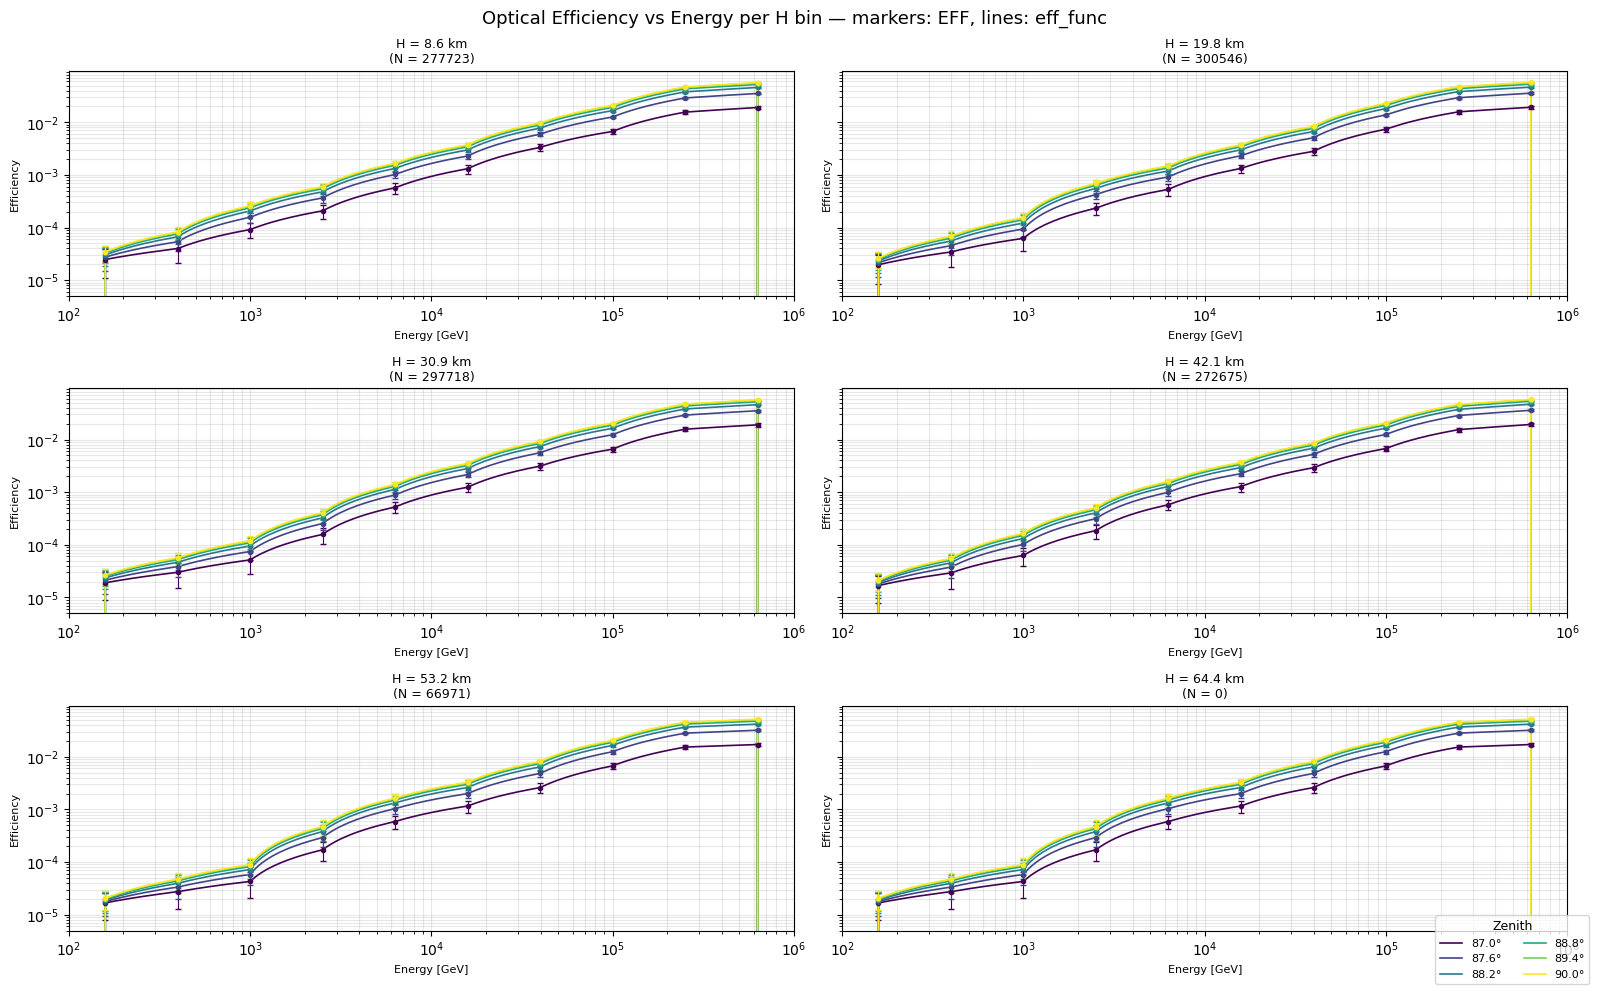

In [6]:
#Testing plot
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(16, 10),
    sharey=True,
)
axes = axes.flatten()

colors = cm.viridis(np.linspace(0, 1, len(Zen_grid)))

# dense E axis for smooth interpolator curves
E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 200)

for j in range(N_H_bins):
    ax = axes[j]
    H_val = H_cen[j]

    for k, zen in enumerate(Zen_grid):
        # --- interpolator (smooth line) ---
        eff_curve = eff_func(E_plot,
                             np.full_like(E_plot, H_val),
                             np.full_like(E_plot, zen))
        ax.plot(
            E_plot, eff_curve,
            color=colors[k],
            linestyle='-',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )

        # --- raw EFF with error bars (markers) ---
        eff_row = EFF[k, j, :]
        valid   = np.isfinite(eff_row)
        if valid.any():
            eff_sigma_pts = eff_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
            )
            ax.errorbar(
                E_cen[valid], eff_row[valid],
                yerr=eff_sigma_pts,
                color=colors[k],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_yscale("log")
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[j,:].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel("Efficiency",   fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(N_H_bins, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Optical Efficiency vs Energy per H bin — markers: EFF, lines: eff_func",
             fontsize=13)
plt.tight_layout()
plt.show()


In [20]:
#FLux Calculation
import pickle
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. Build the efficiency interpolator ONCE from CORSIKA data
# =========================================================================
N_E_bins  = 20
N_H_bins  = 10
N_Z_grid  = 20
E_edges = np.logspace(1,np.log10(1e6),N_E_bins + 1,)
H_edges = np.linspace(3000,100000,N_H_bins + 1,)
Zen_grid = np.linspace(80,90,N_Z_grid,)

# =========================================================================
# 2. Build empirical efficiency cube
# =========================================================================

EFF, STD, COUNTS, E_cen, H_cen, pc_in_bin, GRAD, SIG_FIT, SIG_SCATTER, SIG_TOTAL = efficiency_grid_H_E(
    E_edges,H_edges,Zen_grid,
    Energy_GeV,H,photon_count,
    psi_deg=90.0,phi_max_deg=5.0,n_phi=100,min_pts=5,reduce='mean',
)

# Optional:
# forward-fill sparse high-altitude gaps before interpolation
EFF, GRAD, SIG_SCATTER = ffill_along_H(EFF, GRAD, SIG_SCATTER)

# =========================================================================
# 3. Build (E, slant) photon-count lookup table
# =========================================================================

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges,H,Energy_GeV,photon_count,Zenith,
    n_slant_bins=N_H_bins,
)

# =========================================================================
# 4. Build interpolator
# =========================================================================

eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
    EFF,
    GRAD,
    SIG_SCATTER,
    E_cen,H_cen,
    Zen_grid,S_edges,pc_ES,
    psi_deg=90.0,phi_max_deg=5.0,n_phi=100,min_pts=5,reduce='mean',
)

print("eff(E=1e4 GeV, H=8 km, zen=87°) =",
      eff_func(1e4, 8000.0, 87.0))
print("sigma_eff(E=1e4 GeV, H=8 km, zen=87°) =",
      eff_sigma_func(1e4, 8000.0, 87.0))
print("filled(E=1e4 GeV, H=8 km, zen=87°) =",
      eff_fill_mask_func(1e4, 8000.0, 87.0))



eff(E=1e4 GeV, H=8 km, zen=87°) = 0.0007906027120381471
sigma_eff(E=1e4 GeV, H=8 km, zen=87°) = 0.0003778966552443277
filled(E=1e4 GeV, H=8 km, zen=87°) = False


Extending from largest zenith 89.9503° up to 92.0°
Total zenith bins after extension: 120 (range 91.950° → 80.051°)


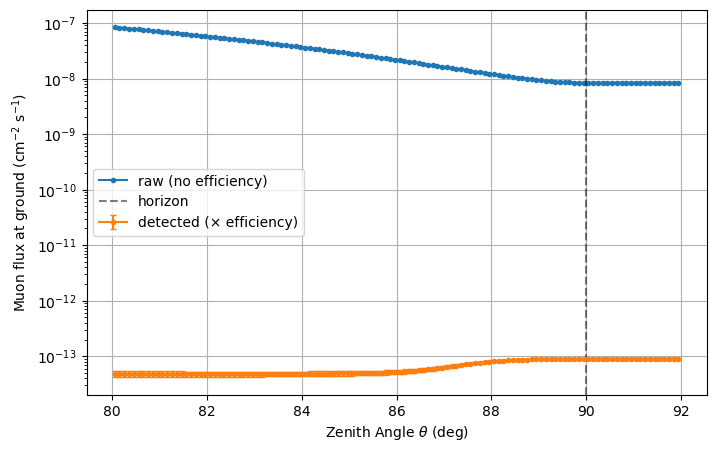

Effective Area (cm^2): 462351.73996121046
Detected muons per hour: 0.012875347531977506 +/- 7.703930469188047e-05
Total muons per hour: 5983.347295416906


In [21]:
#Extrapolate to high zenith
# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
E_GeV           = grid_data['E_GeV']
min_E           = grid_data['min_E']
max_E           = grid_data['max_E']

# --- User-selected zenith window (deg) ---
zen_min_use, zen_max_use = 80, 90.0

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

# --- Azimuth / solid angle settings ---
min_az, max_az = 260, 270
dphi = np.radians(max_az - min_az)
dcos = np.diff(cos_edges)
solid_angles_all = dphi * np.abs(dcos)
solid_angles     = solid_angles_all[zen_mask]

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

# =========================================================================
# 2b. EXTEND to 92° using the largest-zenith MCEq flux (assumed constant)
# =========================================================================
extend_to_deg   = 92.0
extra_bin_width = 0.1  # deg, width of each synthetic zenith bin beyond 90°

# Pick the entry with the LARGEST zenith (closest to horizon)
idx_max = int(np.argmax(zen_centers))
last_entry = selected_entries[idx_max]
last_theta = last_entry['theta']
print(f"Extending from largest zenith {last_theta:.4f}° up to {extend_to_deg}°")

# Build extra zenith centers from (last_theta + dz) up to extend_to_deg
extra_centers = np.arange(last_theta + extra_bin_width,
                          extend_to_deg + 1e-9,
                          extra_bin_width)

# Solid angle for each extra bin: dphi * |cos(th-dz/2) - cos(th+dz/2)|
extra_solid_angles = []
for zc in extra_centers:
    c_lo = np.cos(np.radians(zc - extra_bin_width/2))
    c_hi = np.cos(np.radians(zc + extra_bin_width/2))
    extra_solid_angles.append(dphi * abs(c_lo - c_hi))
extra_solid_angles = np.array(extra_solid_angles)

# Append synthetic entries (copy of last entry, just relabel theta)
for zc in extra_centers:
    synth = {
        'theta'   : zc,
        'd_CDF'   : last_entry['d_CDF'],
        'H_grid'  : last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
    }
    selected_entries.append(synth)

# Build synthetic MCEq entries reusing the largest-zenith data
extra_entries = []
for zc in extra_centers:
    extra_entries.append({
        'theta':    zc,
        'd_CDF':    last_entry['d_CDF'],
        'H_grid':   last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
    })

# After building extra_centers, extra_solid_angles, extra_entries:
zen_centers      = np.concatenate([zen_centers, extra_centers])
solid_angles     = np.concatenate([solid_angles, extra_solid_angles])
selected_entries = selected_entries + extra_entries

# Sort descending (to match original convention) — optional
order = np.argsort(zen_centers)[::-1]
zen_centers      = zen_centers[order]
solid_angles     = solid_angles[order]
selected_entries = [selected_entries[i] for i in order]

print(f"Total zenith bins after extension: {len(zen_centers)} "
      f"(range {zen_centers[0]:.3f}° → {zen_centers[-1]:.3f}°)")

# =========================================================================
# 3. Loop over zenith and apply efficiency via eff_func
# =========================================================================
Total_flux_raw       = []
Total_flux_detected2 = []
Total_flux_detected2_err = []
eff_map = []
eff_map_err = []

for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    sum_mceq = entry['sum_mceq']
    H_m = H_grid / 100.0
    Solid_angle = solid_angles[i]

    # eff_func: clamp zenith query to max available in Zen_grid
    theta_q = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)
    eff_HE2 = eff_func(E_mesh, H_mesh, Z_mesh)
    eff_HE2 = np.nan_to_num(eff_HE2, nan=0.0)
    eff_sigma_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    eff_sigma_HE2 = np.nan_to_num(eff_sigma_HE2, nan=0.0)

    E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_positive = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_positive[-1]

    integrand_HE2 = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    d_CDF_det_E   = np.trapezoid(integrand_HE2[:, E_mask], E_GeV[E_mask], axis=1)
    detected_at_ground2 = np.cumsum(d_CDF_det_E, axis=0)[-1]

    integrand_sigma = np.clip(d_CDF, 0, None) * eff_sigma_HE2 * survival_prob_per_E
    d_CDF_det_E_sigma = np.trapezoid(integrand_sigma[:, E_mask], E_GeV[E_mask], axis=1)
    sigma_detected_at_ground2 = np.sqrt(np.sum(d_CDF_det_E_sigma**2))

    weights = survival_prob_per_E * np.clip(d_CDF, 0, None)
    weight_sum = weights.sum(axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff_vs_E = np.where(
            weight_sum > 0,
            (weights * eff_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        w_norm = np.where(weight_sum > 0, weights / weight_sum, 0.0)
        eff_vs_E_sigma = np.where(
            weight_sum > 0,
            np.sqrt(np.sum((w_norm * eff_sigma_HE2) ** 2, axis=0)),
            np.nan,
        )

    cos_factor = 1
    Total_flux_raw.append(      sum_mceq            * Solid_angle * cos_factor)
    Total_flux_detected2.append(detected_at_ground2 * Solid_angle * cos_factor)
    Total_flux_detected2_err.append(sigma_detected_at_ground2 * Solid_angle * cos_factor)
    eff_map.append(eff_vs_E)
    eff_map_err.append(eff_vs_E_sigma)

Total_flux_raw       = np.array(Total_flux_raw)
Total_flux_detected2 = np.array(Total_flux_detected2)
Total_flux_detected2_err = np.array(Total_flux_detected2_err)
eff_map = np.array(eff_map)
eff_map_err = np.array(eff_map_err)

# --- Plot vs zenith ---
plt.figure(figsize=(8,5))
plt.plot(zen_centers, Total_flux_raw,       '.-', label='raw (no efficiency)')
plt.errorbar(zen_centers, Total_flux_detected2,
             yerr=Total_flux_detected2_err,
             fmt='.-', capsize=2,
             label='detected (× efficiency)')
plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith Angle $\theta$ (deg)')
plt.ylabel(r'Muon flux at ground (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log'); plt.legend(); plt.grid(); plt.show()

# --- Effective area + rate ---
r  = np.linspace(0, 10000, 100)
dr = r[1] - r[0]
m  = (0.02 - 0.005) / (0 - 500)
b  = 0.02
trigger_rate_r = np.clip(m*r + b, 0, None)
trigger_rate_r_normalized = trigger_rate_r / trigger_rate_r.max()
effective_area = 2*np.pi * np.trapezoid(trigger_rate_r_normalized * r, dx=dr)
print("Effective Area (cm^2):", effective_area)

Muon_per_Hour_detected2 = np.sum(Total_flux_detected2) * effective_area * 3600
Muon_per_Hour_total     = np.sum(Total_flux_raw)       * effective_area * 3600
Muon_per_Hour_detected2_err = np.sqrt(np.sum(Total_flux_detected2_err**2)) * effective_area * 3600
print("Detected muons per hour:", Muon_per_Hour_detected2, "+/-", Muon_per_Hour_detected2_err)
print("Total muons per hour:",    Muon_per_Hour_total)

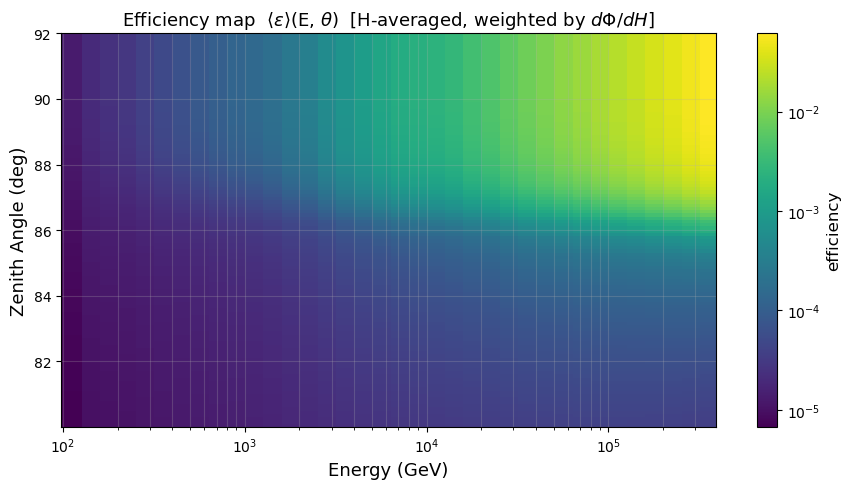

/tmp/ipykernel_659554/1393690209.py:27: RuntimeWarning: invalid value encountered in divide
  err_map = (eff_map_err/eff_map)[:, E_mask_plot]


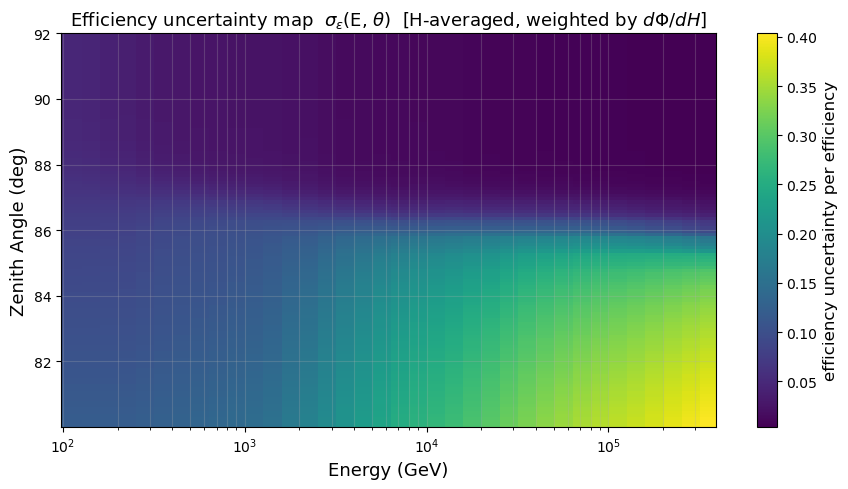

In [27]:
from matplotlib.colors import SymLogNorm

fig, ax = plt.subplots(figsize=(9, 5))
E_mask_plot = (E_GeV > 1e2) & (E_GeV < 4e5)
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    eff_map[:, E_mask_plot],
    shading='auto',
    cmap='viridis',
    norm=SymLogNorm(linthresh=np.min(eff_map[:, E_mask_plot]), linscale=0.5, vmin=None, vmax=None, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
#ax.set_xlim(1e2, 7e5)
ax.set_title(r'Efficiency map  $\langle\varepsilon\rangle$(E, $\theta$)  '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# --- Uncertainty heat map ---
fig, ax = plt.subplots(figsize=(9, 5))
err_map = (eff_map_err/eff_map)[:, E_mask_plot]
err_min = np.nanmin(err_map)
if (not np.isfinite(err_min)) or err_min <= 0:
    err_min = 1e-12
pcm_err = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    err_map,
    shading='auto',
    cmap='viridis',
    #norm=SymLogNorm(linthresh=err_min, linscale=0.5, vmin=None, vmax=None, base=10),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty map  $\sigma_\varepsilon$(E, $\theta$)  '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
cbar = fig.colorbar(pcm_err, ax=ax)
cbar.set_label('efficiency uncertainty per efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

In [28]:
import pickle

eff_map_output = {
    'zen_centers': zen_centers,          # deg, sorted descending
    'E_GeV':       E_GeV,                # energy grid
    'H_grid':      selected_entries[0]['H_grid'],  # cm (same for all entries)
    'eff_map':     eff_map,              # shape (n_zen, n_E)
    'eff_map_err': eff_map_err,          # shape (n_zen, n_E)
    'min_E':       min_E,
    'max_E':       max_E,
    'zen_range':   (zen_min_use, zen_max_use),
    'extend_to_deg': extend_to_deg,
}

out_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(eff_map_output, f)

print(f"Saved eff_map to {out_path}")
print(f"  eff_map shape:     {eff_map.shape}")
print(f"  eff_map_err shape: {eff_map_err.shape}")


Saved eff_map to /uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl
  eff_map shape:     (120, 118)
  eff_map_err shape: (120, 118)


Zenith bins: 120  (91.95° → 80.05°)
Energy bins: 47  (1.12e+01 → 4.47e+05 GeV)
eff_map shape: (120, 47)


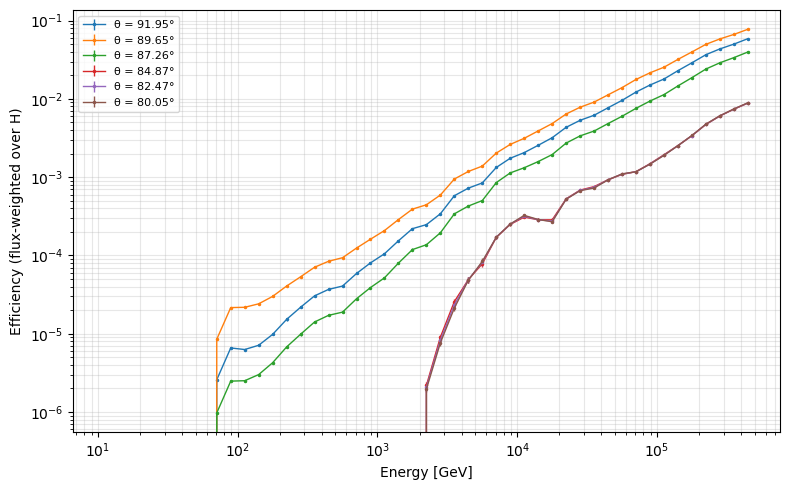

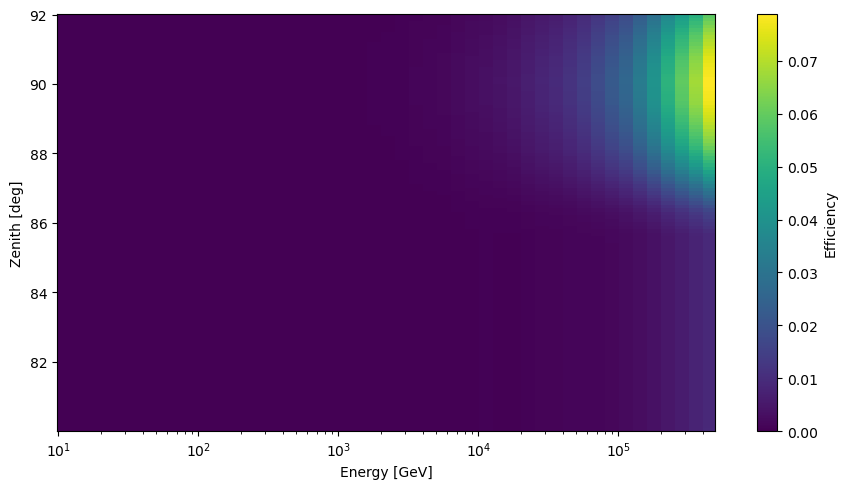